# Modelling cavitation induced gas release dynamics within nozzles

*Experimental - Sanjiv Gunasekera, Daniel Duke*\
*Computational - Nicolὸ Del Santo , Michele Battistoni*

### Manuscript details

#### Journal options
- International Journal of Heat and Mass Transfer

#### Alternate manuscript titles (list below)

#### Instructions for workbook
- Use h3 (###) and h4 (####) only for writing sections and subsections
    - can go down to h5 (#####) code components so that it is easy to collapse and hide cells
- Use blockquotes (>) with initials to comment

#### Libraries
os - for filepaths to be independant of operating system \
dataclass - to replicate matlab struct \
scipy.io - to load .mat matlab files \
panda - openpyxl dependency needs to be installed to load excel data. Jinja2 needed to be installed for table styles. \
pywt - to load wavelet functions \
CoolProp - for thermophysical properties similar to REFPROP but free.

In [1]:
import os
from dataclasses import dataclass
import scipy.io
import numpy as np
import matplotlib
from matplotlib.ticker import AutoMinorLocator
import matplotlib.pyplot as plt
import pandas as pd
import pywt
import CoolProp.CoolProp as CP
# %matplotlib qt5
%matplotlib inline

In [16]:
matplotlib.rcParams['lines.antialiased']          = True
matplotlib.rcParams['text.usetex']                = False
matplotlib.rcParams['font.size']                  = 10
# matplotlib.rcParams['font.family']                = 'serif'
matplotlib.rcParams['font.family']                = 'arial'
matplotlib.rcParams['mathtext.fontset']           = 'custom'
matplotlib.rcParams['mathtext.rm']  = 'arial'
matplotlib.rcParams['xtick.major.pad']            = 8
matplotlib.rcParams['ytick.major.pad']            = 4
matplotlib.rcParams['image.interpolation']        = 'gaussian'
matplotlib.rcParams['image.origin']               = 'lower'
matplotlib.rcParams['ps.papersize']               = 'a4'
matplotlib.rcParams['ps.usedistiller']            = 'xpdf'
matplotlib.rcParams['legend.fontsize']            = 10
matplotlib.rcParams['xtick.major.pad']=12
matplotlib.rcParams['ytick.major.pad']=12
matplotlib.rcParams["figure.dpi"] = 200
matplotlib.rcParams['savefig.dpi'] = 600
matplotlib.rcParams["savefig.bbox"] = 'tight'
matplotlib.rcParams["savefig.pad_inches"] = 0.05
matplotlib.rcParams['figure.max_open_warning'] = 50
figsize = [3.37 ,3.37 ] # 1 column figure
matplotlib.rcParams['figure.figsize'] = figsize # 1 column figure
matplotlib.rcParams['figure.figsize'] = [6.69 ,3.37 ] # 2 column figure

#### User input - values

In [3]:
# Nozzle dimensions
nz_d = 0.54 # mm, if rectangular cross section then height
nz_w = 0 # mm, if circular cross section = 0
nz_l = 3.13 # mm

#### File locations

In [4]:
inDir = r"\\cephfs-smb-rds.erc.monash.edu.au\pharma-sprays\SanjivGunasekera\Experiment\gas_release_img\sensor_data"

calibDir = r"G:\Shared drives\DP23 Cavitation Proj\Calibration data"

# calibDir = r"G:\Shared drives\DP23 Cavitation Proj\Calibration data";
# # calibDir = 'C:\Users\User\Documents\Calibration Data\';
# calibFile_p = 'PT calibration Q2-2024.xlsx'
# # pres_calib_cols = (8, 11, 23);
# # pres_calib_cols = (8, 29, 23);
# # pres_calib_cols = (29, 8, 23);
# pres_calib_cols = (29, 11, 23)


@dataclass
class exp_meta:
    filepath: str
    # label_name: str
    # plt_colour: np.ndarray

exp_case = []

# Calibration - [CO2] = 0 M - no cav.
exp_case.append(exp_meta("14102025_060203_PM"))
exp_case.append(exp_meta("14102025_061711_PM"))
exp_case.append(exp_meta("14102025_062923_PM"))
exp_case.append(exp_meta("14102025_064519_PM"))
exp_case.append(exp_meta("14102025_072120_PM"))

# Calibration - [CO2] = 100 M - no cav.
exp_case.append(exp_meta("01102025_062434_PM"))
exp_case.append(exp_meta("01102025_081634_PM"))
exp_case.append(exp_meta("07102025_072640_PM"))
exp_case.append(exp_meta("07102025_091112_PM"))

# Experiment - K = 1.33
exp_case.append(exp_meta("14102025_070455_PM"))
exp_case.append(exp_meta("22102025_035732_PM"))
exp_case.append(exp_meta("22102025_072537_PM"))
exp_case.append(exp_meta("22102025_082040_PM"))
exp_case.append(exp_meta("13102025_034025_PM"))

# Experiment - K = 1.12
exp_case.append(exp_meta("16102025_020815_PM"))
exp_case.append(exp_meta("16102025_055437_PM"))
exp_case.append(exp_meta("16102025_024015_PM"))
exp_case.append(exp_meta("16102025_124016_PM"))

# Experiment - K = 1.06
exp_case.append(exp_meta("21102025_023020_PM"))
exp_case.append(exp_meta("21102025_035756_PM"))
# exp_case.append(exp_meta("21102025_025416_PM")) # fluid might have been contaminated
exp_case.append(exp_meta("14112025_121214_PM"))
exp_case.append(exp_meta("21102025_053943_PM"))
exp_case.append(exp_meta("21102025_065756_PM"))

#### Load experiment data
Both the cavitation experiment related data and signals together with the dissolved gas levels are imported here

In [5]:
CavNum = np.full((len(exp_case), 4), np.nan)
c_D = np.full((len(exp_case), 2), np.nan)
Re = np.full((len(exp_case), 2), np.nan)
co2_conc = np.full((len(exp_case), 2), np.nan)
cond_up_vals = []
cond_down_vals = []
pH_vals = []
p1_vals = []
p2_vals = []
p3_mean = []
f1_vals = []
svp1 = np.full((len(exp_case), 1), np.nan)
dens1 = np.full((len(exp_case), 1), np.nan)
dynvis1 = np.full((len(exp_case), 1), np.nan)
ai_time = []
teensy_time = []
tstart_diff = np.full((len(exp_case), 1), np.nan)
tstart_delay = np.full((len(exp_case), 1), np.nan)
stab_ai_wind = np.full((len(exp_case), 2), -1, dtype=int)

for j in range(len(exp_case)):
    # Cavitation data
    temp_var = scipy.io.loadmat(os.path.join(inDir, "nzflow_summary_" + exp_case[j].filepath + ".mat"))

    CavNum[j, 0] = temp_var['CavNum_val_mean'].item()
    CavNum[j, 1] = temp_var['CavNum_val_std'].item()
    CavNum[j, 2] = temp_var['sqrt_K_mean'].item()
    CavNum[j, 3] = temp_var['sqrt_K_std'].item()

    c_D[j, 0] = temp_var["dsch_coef_mean"].item()
    c_D[j, 1] = temp_var["dsch_coef_std"].item()

    Re[j, 0] = temp_var["Re_val_mean"].item()
    Re[j, 1] = temp_var["Re_val_std"].item()

    cond_up_vals.append(temp_var["cond_up_vals"].flatten())
    cond_down_vals.append(temp_var["cond_down_vals"].flatten())
    pH_vals.append(temp_var["pH_vals"].flatten())

    p1_vals.append(temp_var["p1_vals"].flatten())
    p2_vals.append(temp_var["p2_vals"].flatten())
    f1_vals.append(temp_var["f1_vals"].flatten())

    svp1[j, 0] = temp_var["svp1"].item()
    dens1[j, 0] = temp_var["dens1"].item()
    dynvis1[j, 0] = temp_var["dynvis1"].item()

    teensy_time.append(temp_var["teensy_time"].flatten())
    ai_time.append(temp_var["ai_time"].flatten())
    tstart_diff[j, 0] = temp_var["tstart_ai_teensy"].item()
    tstart_delay[j, 0] = temp_var["tstart_delay"].item()

    stab_ai_wind[j, 0] = int(temp_var["img_start_ai_ind"].item())
    stab_ai_wind[j, 1] = int(temp_var["img_end_ai_ind"].item())

    # Dissolved gas data
    temp_var = scipy.io.loadmat(os.path.join(inDir, "disgas_calcs",  "disgas_calcs_" + exp_case[j].filepath + ".mat"))

    co2_conc[j, 0] = temp_var['dis_co2_mole_c'].item()
    co2_conc[j, 1] = temp_var['dis_co2_mole_c_err'].item()

    temp_p3 = temp_var['dis_p3_vals'].flatten()
    if np.isnan(temp_var['dis_fin'].item()).item():
        temp_p3_mean = 0
    else:
        temp_p3_mean = np.mean(temp_p3[temp_var['dis_fin'].item():-1])
    p3_mean.append(temp_p3_mean)

p3_mean = np.array(p3_mean)

### Introduction

### Methodology

- Controlled upstream pressure maintained with charged accumulator.
- Downstream pressure controlled by the back-pressure regulator.
- Slow flow through sparging stone till vacuumed tank reaches target dissolution pressure. 
> SG - Minimise this detail and cite [Gunasekera and Duke 2025] paper

- Conductivity sensor located before and after nozzle (upstream for control).
- pH sensor located downstream of nozzle. 

<!-- ![schematics of experiment and nozzle](.\figures\experiment_facility.png) -->
![schematics of experiment and nozzle](experiment_facility.png)

#### Detect experiment start and end

Used a Haar transform with mass flowrate to determine the start and end of the experiment.

In [6]:
tstart_ind = np.full((len(exp_case), 1), -1, dtype=int)
tend_ind = np.full((len(exp_case), 1), -1, dtype=int)
tstart_teensy_ind = np.full((len(exp_case), 1), -1, dtype=int)
tend_teensy_ind = np.full((len(exp_case), 1), -1, dtype=int)
stab_teensy_wind = np.full((len(exp_case), 2), -1, dtype=int)
stat_ai_wind = np.full((len(exp_case), 2), -1, dtype=int)
stat_teensy_wind = np.full((len(exp_case), 2), -1, dtype=int)

cond_t_delay_ind = 20000*30 # samples per second * seconds to delay
pH_t_delay_ind = 4*30 # samples per second * seconds to delay

for exp_num in range(len(exp_case)):   

    # cA, cD = pywt.dwt(f1_vals[0][1000:], 'haar', )
    coeffs = pywt.wavedec(f1_vals[exp_num][1000:], wavelet='haar', level=18)
    # coeffs = pywt.wavedec(p1_vals[exp_num][1000:]-p2_vals[exp_num][1000:], wavelet='haar', level=18)
    for j in range(-14,-1):
        coeffs[j] = np.zeros_like(coeffs[j])

    # x_rec = pywt.idwt(cA, cD, 'haar')
    # x_rec = pywt.idwt(cA, cD, 'haar')
    x_rec = pywt.waverec(coeffs, wavelet='haar')

    tstart_ind[exp_num] = np.argmax(np.diff(x_rec))  
    tend_ind[exp_num] = np.argmin(np.diff(x_rec)) 
    
    tstart_teensy_ind[exp_num] = np.where(teensy_time[exp_num][:]>ai_time[exp_num][tstart_ind[exp_num]]+tstart_diff[exp_num])[0][0]  
    tend_teensy_ind[exp_num] = np.where(teensy_time[exp_num]>ai_time[exp_num][tend_ind[exp_num]]+tstart_diff[exp_num])[0][0]

    stab_teensy_wind[exp_num, 0] = np.where(teensy_time[exp_num][:]>ai_time[exp_num][stab_ai_wind[exp_num, 0]]+tstart_diff[exp_num])[0][0]
    stab_teensy_wind[exp_num, 1] = np.where(teensy_time[exp_num]>ai_time[exp_num][stab_ai_wind[exp_num, 1]]+tstart_diff[exp_num])[0][0]
    # print(f"Exp {exp_num}: tstart = {ai_time[exp_num][tstart_ind[exp_num,0]]:.2f} s; tend = {ai_time[exp_num][tend_ind[exp_num,0]]:.2f} s")
    # print(f"Exp {exp_num}: tstart = {teensy_time[exp_num][tstart_teensy_ind[exp_num,0]]:.2f} s; tend = {teensy_time[exp_num][tend_teensy_ind[exp_num,0]]:.2f} s")

    if tstart_ind[exp_num,0]+cond_t_delay_ind > stab_ai_wind[exp_num, 0]:
        stat_ai_wind[exp_num,0] = tstart_ind[exp_num,0]+cond_t_delay_ind
        stat_teensy_wind[exp_num,0] = tstart_teensy_ind[exp_num,0]+pH_t_delay_ind
    else:
        stat_ai_wind[exp_num,0] = stab_ai_wind[exp_num, 0]
        stat_teensy_wind[exp_num,0] = stab_teensy_wind[exp_num,0]
    
stat_ai_wind[:,1] = tend_ind[:,0]
stat_teensy_wind[:,1] = tend_teensy_ind[:,0]

#### Calculate average conductivity and pH values

- Currently calculating mean and std using the time window detected with the Haar transform.
> SG - Will try to compare with tiem window obtained from pressure stable period detection. 
- Illustration of the time windows against the conductivity signals is shown below. 

In [7]:
cond_up_stats = np.full((len(exp_case), 2), np.nan)
cond_down_stats = np.full((len(exp_case), 2), np.nan)
cond_diff_stats = np.full((len(exp_case), 2), np.nan)
pH_stats = np.full((len(exp_case), 2), np.nan)
p1_stats = np.full((len(exp_case), 2), np.nan)
p2_stats = np.full((len(exp_case), 2), np.nan)
delp_stats = np.full((len(exp_case), 2), np.nan)
qflow_stats = np.full((len(exp_case), 2), np.nan)

for exp_num in range(len(exp_case)):
    p2_stats[exp_num, 0] = np.mean(p2_vals[exp_num][stat_ai_wind[exp_num,0] : stat_ai_wind[exp_num,1]])
    p2_stats[exp_num, 1] = np.std(p2_vals[exp_num][stat_ai_wind[exp_num,0] : stat_ai_wind[exp_num,1]])

    p1_stats[exp_num, 0] = np.mean(p1_vals[exp_num][stat_ai_wind[exp_num,0] : stat_ai_wind[exp_num,1]])
    p1_stats[exp_num, 1] = np.std(p1_vals[exp_num][stat_ai_wind[exp_num,0] : stat_ai_wind[exp_num,1]])

    delp_stats[exp_num, 0] = np.mean(p1_vals[exp_num][stat_ai_wind[exp_num,0] : stat_ai_wind[exp_num,1]] - p2_vals[exp_num][stat_ai_wind[exp_num,0] : stat_ai_wind[exp_num,1]])
    delp_stats[exp_num, 1] = np.std(p1_vals[exp_num][stat_ai_wind[exp_num,0] : stat_ai_wind[exp_num,1]] - p2_vals[exp_num][stat_ai_wind[exp_num,0] : stat_ai_wind[exp_num,1]])

    cond_up_stats[exp_num, 0] = np.mean(cond_up_vals[exp_num][stat_ai_wind[exp_num,0] : stat_ai_wind[exp_num,1]])
    cond_up_stats[exp_num, 1] = np.std(cond_up_vals[exp_num][stat_ai_wind[exp_num,0] : stat_ai_wind[exp_num,1]])

    cond_down_stats[exp_num, 0] = np.mean(cond_down_vals[exp_num][stat_ai_wind[exp_num,0] : stat_ai_wind[exp_num,1]])
    cond_down_stats[exp_num, 1] = np.std(cond_down_vals[exp_num][stat_ai_wind[exp_num,0] : stat_ai_wind[exp_num,1]])

    cond_diff_stats[exp_num, 0] = cond_up_stats[exp_num, 0] - cond_down_stats[exp_num, 0]
    cond_diff_stats[exp_num, 1] = np.sqrt(cond_up_stats[exp_num, 1]**2 + cond_down_stats[exp_num, 1]**2)

    pH_stats[exp_num, 0] = np.mean(pH_vals[exp_num][stat_teensy_wind[exp_num,0] : stat_teensy_wind[exp_num,1]])
    pH_stats[exp_num, 1] = np.std(pH_vals[exp_num][stat_teensy_wind[exp_num,0] : stat_teensy_wind[exp_num,1]])

    qflow_stats[exp_num, 0] = np.mean(f1_vals[exp_num][stat_ai_wind[exp_num,0] : stat_ai_wind[exp_num,1]]/(dens1[exp_num,0]*60)) # volumetric flowrate m3/min
    qflow_stats[exp_num, 1] = np.std(f1_vals[exp_num][stat_ai_wind[exp_num,0] : stat_ai_wind[exp_num,1]]/(dens1[exp_num,0]*60)) # volumetric flowrate m3/min


<>:19: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:19: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\sgun0045\AppData\Local\Temp\ipykernel_111308\830741025.py:19: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.ylabel('conductivity down [$\mu$S/cm]');


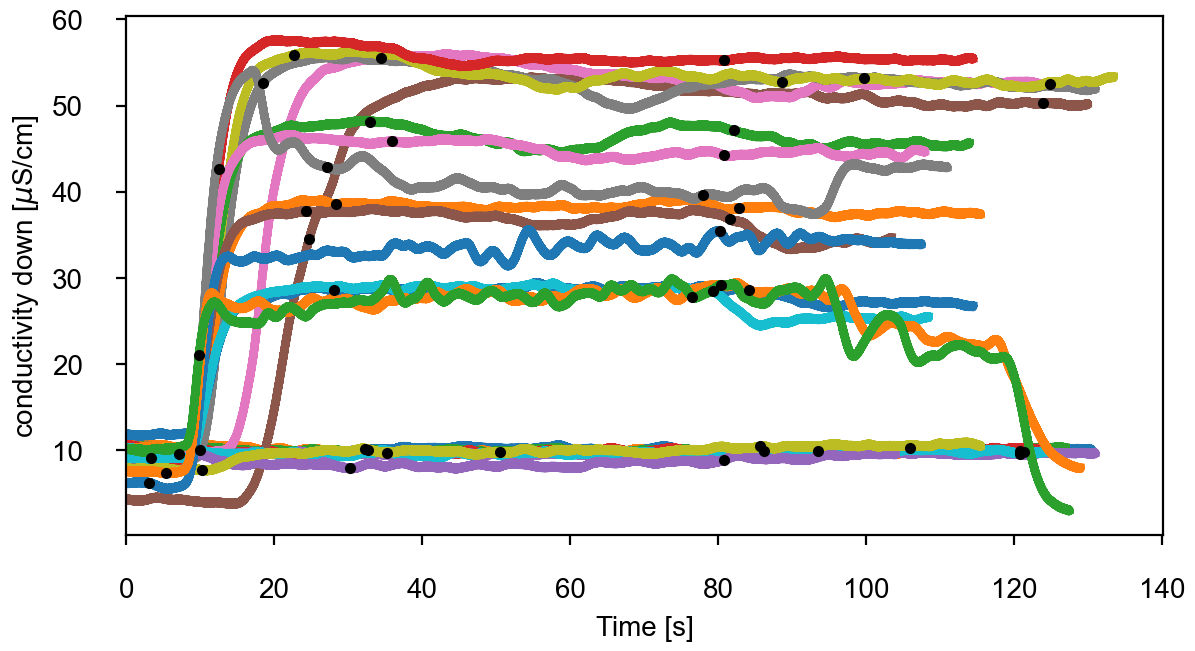

In [8]:
plt.figure()

for exp_num in range(len(exp_case)):
# for exp_num in (0,1):

# plt.xlim(20, 21)
# plt.ylim(174, 178)
    # pH
    # plt.plot(teensy_time[exp_num]-tstart_diff[exp_num], pH_vals[exp_num], linewidth=3)
    # plt.ylabel('pH');
    # # plt.scatter(teensy_time[exp_num][tstart_teensy_ind[exp_num,0]]-tstart_diff[exp_num], pH_vals[exp_num][tstart_teensy_ind[exp_num,0]], s=50, c=(0,0,0), zorder=10)
    # # plt.plot(teensy_time[exp_num][tstart_teensy_ind[exp_num,0]+pH_t_delay_ind]-tstart_diff[exp_num], pH_vals[exp_num][tstart_teensy_ind[exp_num,0]+pH_t_delay_ind], ls='none', c=(0,0,0), marker='.', zorder=10)
    # # plt.plot(teensy_time[exp_num][tend_teensy_ind[exp_num,0]]-tstart_diff[exp_num], pH_vals[exp_num][tend_teensy_ind[exp_num,0]], ls='none', c=(0,0,0), marker='.', zorder=10)
    # plt.plot(teensy_time[exp_num][stab_teensy_wind[exp_num,0]+pH_t_delay_ind]-tstart_diff[exp_num], pH_vals[exp_num][stab_teensy_wind[exp_num,0]+pH_t_delay_ind], ls='none', c=(0,0,0), marker='.', zorder=10)
    # plt.plot(teensy_time[exp_num][stab_teensy_wind[exp_num,1]]-tstart_diff[exp_num], pH_vals[exp_num][stab_teensy_wind[exp_num,1]], ls='none', c=(0,0,0), marker='.', zorder=10)
    
    # conductivity
    plt.plot(ai_time[exp_num][1000:], cond_down_vals[exp_num][1000:], linewidth=3)
    plt.ylabel('conductivity down [$\mu$S/cm]');
    # plt.plot(ai_time[exp_num][tstart_ind[exp_num,0]+cond_t_delay_ind], cond_down_vals[exp_num][tstart_ind[exp_num,0]+cond_t_delay_ind], ls='none', marker='.', color=(0,0,0), zorder=10)
    # plt.plot(ai_time[exp_num][tend_ind[exp_num,0]], cond_down_vals[exp_num][tend_ind[exp_num,0]], ls='none', marker='.', color=(0,0,0), zorder=10)
    # plt.plot(ai_time[exp_num][int(stab_ai_wind[exp_num,0])+cond_t_delay_ind], cond_down_vals[exp_num][int(stab_ai_wind[exp_num,0])+cond_t_delay_ind], ls='none', marker='.', color=(0,0,0), zorder=10)
    plt.plot(ai_time[exp_num][stab_ai_wind[exp_num,0]], cond_down_vals[exp_num][stab_ai_wind[exp_num,0]], ls='none', marker='.', color=(0,0,0), zorder=10)
    plt.plot(ai_time[exp_num][stab_ai_wind[exp_num,1]], cond_down_vals[exp_num][stab_ai_wind[exp_num,1]], ls='none', marker='.', color=(0,0,0), zorder=10)
    
plt.xlim(0,)

plt.xlabel('Time [s]');
plt.show()

#### Conductivity sensor calibrations

- These checks have been done to establish if the conductivity measurements are dependent on the Reynolds number. 
- The conductivity values are quite consistent across varying Reynolds number for a given CO2 concentration. 

In [9]:
# Table for degassed and dissolved gas experiments without cavitation

# plt_exp = 0, 1, 2, 3, 9, 4 # degas - no cav. with check for contamination
plt_exp1 = 0, 1, 2, 3, 9 # degas - no cav.
table_caption1 = "Conductivity statistics for degassed experiments without cavitation."
plt_exp2 = 5, 6, 7, 8, 13 # dis gas - no cav.
table_caption2 = "Conductivity statistics for high dissolved CO2 experiments without cavitation."
# plt_exp = 9, 10, 11, 12, 13 # K = 1.37
# plt_exp = 14, 15, 16, 17 # K = 1.12
# plt_exp = 18, 19, 20, 21, 22 # K = 1.06

table_data1 = {}
for j in plt_exp1:
    table_data1[f"Re = {Re[j, 0]:.0f} \u00B1  {2*Re[j, 1]:.0f}"] = [f"{cond_up_stats[j, 0]:.1f} \u00B1  {2*cond_up_stats[j, 1]:.1f}", f"{cond_down_stats[j, 0]:.1f} \u00B1  {2*cond_down_stats[j, 1]:.1f}", f"{co2_conc[j, 0]:.1f} \u00B1  {2*co2_conc[j, 1]:.1f}"]

df1 = pd.DataFrame(table_data1, index=["Conductivity upstream [\u03bcS/cm]", "Conductivity downstream [\u03bcS/cm]", "Dissolved CO2 concentration [mol/m3]"])

# display(df1.style.set_caption(table_caption1))
display(df1)


table_data2 = {}
for j in plt_exp2:
    table_data2[f"Re = {Re[j, 0]:.0f} \u00B1  {2*Re[j, 1]:.0f}"] = [f"{cond_up_stats[j, 0]:.1f} \u00B1  {2*cond_up_stats[j, 1]:.1f}", f"{cond_down_stats[j, 0]:.1f} \u00B1  {2*cond_down_stats[j, 1]:.1f}", f"{co2_conc[j, 0]:.1f} \u00B1  {2*co2_conc[j, 1]:.1f}"]

df2 = pd.DataFrame(table_data2, index=["Conductivity upstream [\u03bcS/cm]", "Conductivity downstream [\u03bcS/cm]", "Dissolved CO2 concentration [mol/m3]"])

# display(df2.style.set_caption(table_caption2))
display(df2)

,Re = 9890 ± 125,Re = 14607 ± 133,Re = 18622 ± 132,Re = 21344 ± 135,Re = 23301 ± 129
Conductivity upstream [μS/cm],10.1 ± 0.3,9.9 ± 0.3,10.1 ± 0.4,9.9 ± 0.6,9.8 ± 0.4
Conductivity downstream [μS/cm],10.1 ± 0.4,9.9 ± 0.2,10.0 ± 0.3,9.9 ± 0.3,9.8 ± 0.4
Dissolved CO2 concentration [mol/m3],0.0 ± 0.1,0.0 ± 0.1,0.0 ± 0.1,0.0 ± 0.1,0.0 ± 0.1


,Re = 12185 ± 124,Re = 16194 ± 128,Re = 19313 ± 128,Re = 21908 ± 134,Re = 23767 ± 134
Conductivity upstream [μS/cm],54.0 ± 2.6,54.0 ± 2.7,54.1 ± 2.4,54.5 ± 1.4,56.6 ± 0.8
Conductivity downstream [μS/cm],51.7 ± 2.2,53.4 ± 2.8,53.0 ± 2.7,53.5 ± 1.9,55.4 ± 0.9
Dissolved CO2 concentration [mol/m3],110.5 ± 2.8,110.0 ± 2.8,109.2 ± 2.8,110.1 ± 2.8,111.4 ± 2.8


<>:16: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:16: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\sgun0045\AppData\Local\Temp\ipykernel_111308\770600589.py:16: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  axs[0].set_ylabel('Conductivity [$\mu$S/cm]', color=(0.5,0,0))


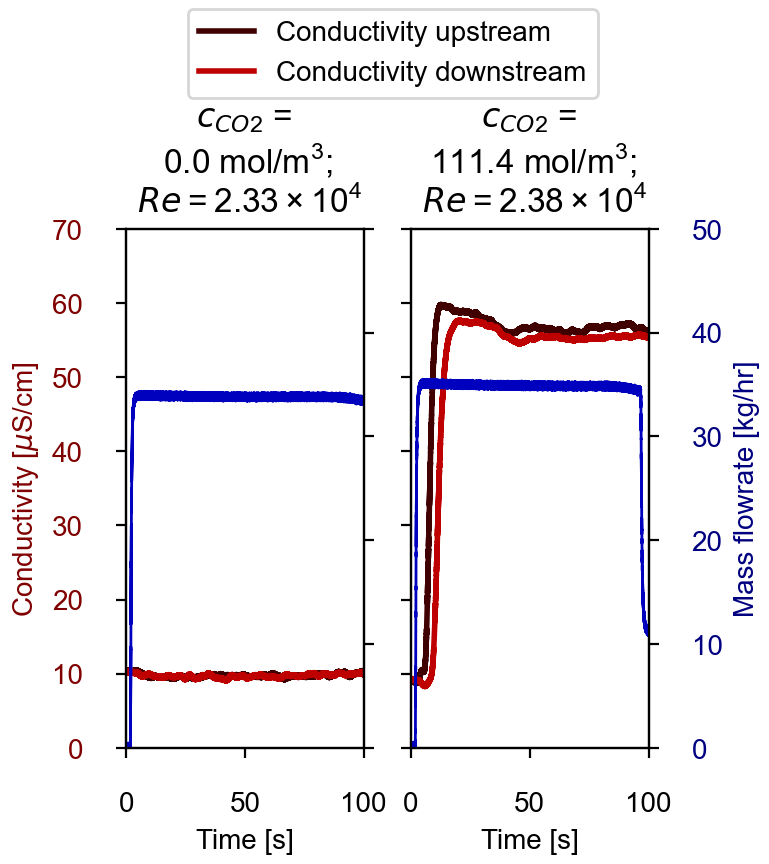

In [19]:
# Figure - Sample conductivity and mass flowrate signals

figsize = [3.37 ,3.37 ] # 1 column figure
matplotlib.rcParams['figure.figsize'] = figsize # 1 column figure

cond_lim = 0, 70
time_lim = 0, 100
mflow_lim = 0, 50

fig, axs = plt.subplots(1, 2)
axs_twin = np.empty_like(axs, dtype=object)

exp_num = 9
axs[0].plot(ai_time[exp_num][1000:], cond_up_vals[exp_num][1000:], color=(0.25,0,0), linewidth=2, label='Conductivity upstream')
axs[0].plot(ai_time[exp_num][1000:], cond_down_vals[exp_num][1000:], color=(0.75,0,0), linewidth=2, label='Conductivity downstream')
axs[0].set_ylabel('Conductivity [$\mu$S/cm]', color=(0.5,0,0))
axs[0].set_xlabel('Time [s]')
axs[0].set_xlim(time_lim)
axs[0].set_ylim(cond_lim)
axs[0].tick_params(axis='y', labelcolor=(0.5,0,0), labelleft=True)
axs[0].legend(loc='upper left', bbox_to_anchor=(0.2, 1.45), ncol=1, frameon=True);
axs[0].set_title(f"$c_{{CO2}}$ = \n ${co2_conc[exp_num,0]:.1f}$ mol/m$^3$; \n $Re = {Re[exp_num,0]/10**4:.2f} \\times 10^4$")


axs_twin[0] = axs[0].twinx()
axs_twin[0].plot(ai_time[exp_num][1000:], f1_vals[exp_num][1000:], color=(0,0,0.75), linewidth=1, label='_Mass flowrate')
axs_twin[0].set_ylim(mflow_lim)
axs_twin[0].tick_params(axis='y', labelright=False)


exp_num = 13
axs[1].plot(ai_time[exp_num][1000:], cond_up_vals[exp_num][1000:], color=(0.25,0,0), linewidth=2, label='_Conductivity upstream')
axs[1].plot(ai_time[exp_num][1000:], cond_down_vals[exp_num][1000:], color=(0.75,0,0), linewidth=2, label='_Conductivity downstream')
axs[1].set_xlabel('Time [s]')
axs[1].set_xlim(time_lim)
axs[1].set_ylim(cond_lim)
axs[1].tick_params(axis='y', labelleft=False)
axs[1].set_title(f"$c_{{CO2}}$ = \n ${co2_conc[exp_num,0]:.1f}$ mol/m$^3$; \n $Re = {Re[exp_num,0]/10**4:.2f} \\times 10^4$")


axs_twin[1] = axs[1].twinx()
axs_twin[1].plot(ai_time[exp_num][1000:], f1_vals[exp_num][1000:], color=(0,0,0.75), linewidth=1, label='_Mass flowrate')
axs_twin[1].set_ylim(mflow_lim)
axs_twin[1].set_ylabel('Mass flowrate [kg/hr]', color=(0,0,0.5))
axs_twin[1].tick_params(axis='y', labelcolor=(0,0,0.5), labelright=True)

# plt.tight_layout()
plt.show()


- The following table shows the conductivity with the dissolved CO2 concentration when the flow is not cavitating. Cavitation threshold is approximately K = 1.33.
> SG - Cite literature that has compared dissolved CO2 with conductivity and compare behaviour. From what I remember there was a paper that mentioned the relationship was linear. 

In [12]:
# Table for varying dissolved CO2 concentration

# plt_exp = 0, 1, 2, 3, 9, 4 # degas - no cav. with check for contamination
# plt_exp1 = 0, 1, 2, 3, 9 # degas - no cav.
# table_caption1 = "Conductivity statistics for degassed experiments without cavitation."
# plt_exp2 = 5, 6, 7, 8, 13 # dis gas - no cav.
# table_caption2 = "Conductivity statistics for high dissolved CO2 experiments without cavitation."
plt_exp3 = 9, 10, 11, 12, 13 # K = 1.37
table_caption3 = "Conductivity statistics with varying dissolved CO2 concentration without cavitation."
# plt_exp = 14, 15, 16, 17 # K = 1.12
# plt_exp = 18, 19, 20, 21, 22 # K = 1.06

table_data3 = {}
for j in plt_exp3:
    table_data3[f"[CO2] = {co2_conc[j, 0]:.1f} \u00B1  {2*co2_conc[j, 1]:.1f} mol/m3"] = [f"{cond_up_stats[j, 0]:.1f} \u00B1  {2*cond_up_stats[j, 1]:.1f}", f"{cond_down_stats[j, 0]:.1f} \u00B1  {2*cond_down_stats[j, 1]:.1f}", f"{Re[j, 0]:.0f} \u00B1  {2*Re[j, 1]:.0f}", f"{CavNum[j, 0]:.2f} \u00B1  {2*CavNum[j, 1]:.2f}"]

df3 = pd.DataFrame(table_data3, index=["Conductivity upstream [\u03bcS/cm]", "Conductivity downstream [\u03bcS/cm]", "Reynolds number [-]", "Cavitation number [-]"])

# display(df3.style.set_caption(table_caption3))
display(df3)

,[CO2] = 0.0 ± 0.1 mol/m3,[CO2] = 26.1 ± 2.8 mol/m3,[CO2] = 54.6 ± 2.8 mol/m3,[CO2] = 82.5 ± 2.8 mol/m3,[CO2] = 111.4 ± 2.8 mol/m3
Conductivity upstream [μS/cm],9.8 ± 0.4,28.8 ± 2.0,38.8 ± 1.4,47.3 ± 2.2,56.6 ± 0.8
Conductivity downstream [μS/cm],9.8 ± 0.4,28.5 ± 1.3,38.3 ± 0.9,46.4 ± 2.1,55.4 ± 0.9
Reynolds number [-],23301 ± 129,23559 ± 147,23503 ± 141,23488 ± 134,23767 ± 134
Cavitation number [-],1.39 ± 0.00,1.37 ± 0.00,1.37 ± 0.00,1.37 ± 0.00,1.37 ± 0.00


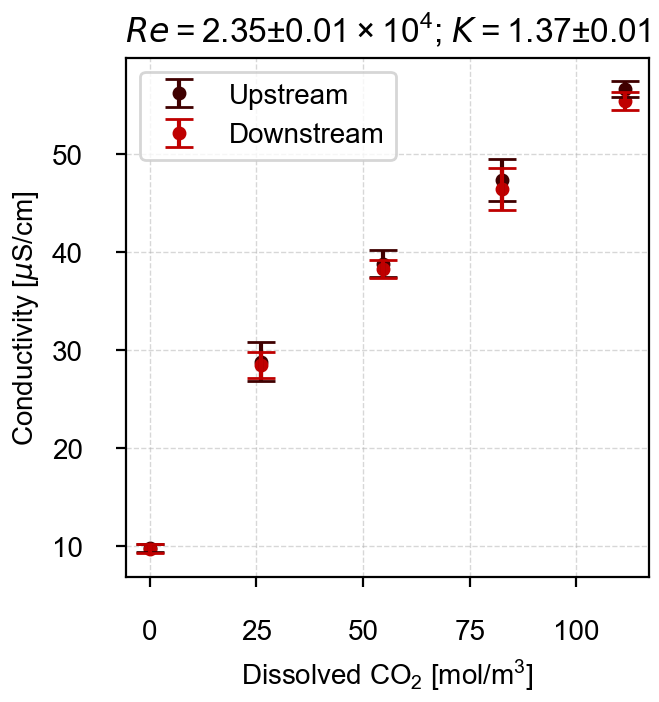

In [21]:
# Figure for conductivity vs dissolved CO2 concentration when not cavitating

figsize = [3.37 ,3.37 ] # 1 column figure
matplotlib.rcParams['figure.figsize'] = figsize # 1 column figure

# plt_exp = 0, 1, 2, 3, 9, 4 # degas - no cav. with check for contamination
# plt_exp1 = 0, 1, 2, 3, 9 # degas - no cav.
# table_caption1 = "Conductivity statistics for degassed experiments without cavitation."
# plt_exp2 = 5, 6, 7, 8, 13 # dis gas - no cav.
# table_caption2 = "Conductivity statistics for high dissolved CO2 experiments without cavitation."
plt_exp3 = 9, 10, 11, 12, 13 # K = 1.37
# plt_exp = 14, 15, 16, 17 # K = 1.12
# plt_exp = 18, 19, 20, 21, 22 # K = 1.06

# Assuming that the number of samples are so high so combining the standard deviations without the sample size factor is fine
CavNum_plt = []
CavNum_plt.append(np.mean(CavNum[plt_exp3, 0]))
CavNum_plt.append(np.sqrt(np.sum(CavNum[plt_exp3, 1]**2)/np.size(plt_exp3)))

Re_plt = []
Re_plt.append(np.mean(Re[plt_exp3, 0]))
Re_plt.append(np.sqrt(np.sum(Re[plt_exp3, 1]**2)/np.size(plt_exp3)))

fig, ax = plt.subplots()

ax.errorbar(co2_conc[plt_exp3, 0], cond_up_stats[plt_exp3, 0], yerr=2*cond_up_stats[plt_exp3, 1], fmt='o', markersize=4, label='Upstream', color=(0.25,0,0), capsize=5, barsabove=True)
ax.errorbar(co2_conc[plt_exp3, 0], cond_down_stats[plt_exp3, 0], yerr=2*cond_down_stats[plt_exp3, 1], fmt='o', markersize=4, label='Downstream', color=(0.75,0,0), capsize=5, barsabove=True)
ax.set_xlabel('Dissolved CO$_2$ [mol/m$^3$]')
ax.set_ylabel('Conductivity [$\\mu$S/cm]')
ax.grid(which='both', linestyle='--', linewidth=0.5, alpha=0.5)
ax.legend(frameon=True, loc='upper left');
ax.set_title(f"$Re = {Re_plt[0]/10**4:.2f} \u00B1  {max(2*Re_plt[1]/10**4, 0.01):.2f} \\times 10^4$; $K = {CavNum_plt[0]:.2f} \u00B1  {max(2*CavNum_plt[1], 0.01):.2f}$");

plt.show()


#### Quantification of gas release - conductivity

- The upstream conductivity is comparable across experiments regardless of the cavitation number.
> SG - The K = 1.06, [CO2] = 50 M needs to be run again as it doesn't follow the above sentence and it doesnt make a lot of sense why it shouldn't.\
>\
> SG - Add example instantaneous/mean/std images of the nozzle at these two conditions. 
>> SG - Might take a lot of time if we were to get pictures for all the conditions though. So probably need to select some useful conditions. Ideally select three cases with the same [CO2].

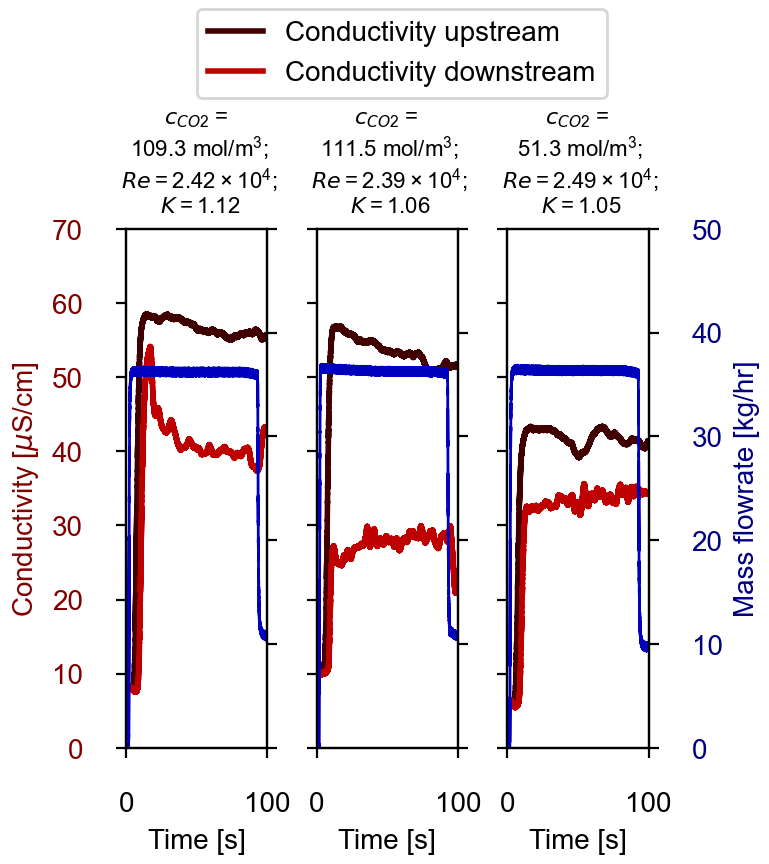

In [70]:
# Figure - Examples of conductivity decrease downstream

figsize = [3.37 ,3.37 ] # 1 column figure
matplotlib.rcParams['figure.figsize'] = figsize # 1 column figure

cond_lim = 0, 70
time_lim = 0, 100
mflow_lim = 0, 50

fig, axs = plt.subplots(1, 3)
axs_twin = np.empty_like(axs, dtype=object)

exp_num = 17
axs[0].plot(ai_time[exp_num][1000:], cond_up_vals[exp_num][1000:], color=(0.25,0,0), linewidth=2, label='Conductivity upstream')
axs[0].plot(ai_time[exp_num][1000:], cond_down_vals[exp_num][1000:], color=(0.75,0,0), linewidth=2, label='Conductivity downstream')
axs[0].set_ylabel('Conductivity [$\\mu$S/cm]', color=(0.5,0,0))
axs[0].set_xlabel('Time [s]')
axs[0].set_xlim(time_lim)
axs[0].set_ylim(cond_lim)
axs[0].tick_params(axis='y', labelcolor=(0.5,0,0), labelleft=True)
axs[0].legend(loc='upper left', bbox_to_anchor=(0.4, 1.45), ncol=1, frameon=True);
axs[0].set_title(f"$c_{{CO2}}$ = \n {co2_conc[exp_num,0]:.1f} mol/m$^3$; \n $Re = {Re[exp_num,0]/10**4:.2f} \\times 10^4$; \n $K = {CavNum[exp_num,0]:.2f}$", fontsize=8)


axs_twin[0] = axs[0].twinx()
axs_twin[0].plot(ai_time[exp_num][1000:], f1_vals[exp_num][1000:], color=(0,0,0.75), linewidth=1, label='_Mass flowrate')
axs_twin[0].set_ylim(mflow_lim)
axs_twin[0].tick_params(axis='y', labelright=False)


exp_num = 22
axs[1].plot(ai_time[exp_num][1000:], cond_up_vals[exp_num][1000:], color=(0.25,0,0), linewidth=2, label='_Conductivity upstream')
axs[1].plot(ai_time[exp_num][1000:], cond_down_vals[exp_num][1000:], color=(0.75,0,0), linewidth=2, label='_Conductivity downstream')
axs[1].set_xlabel('Time [s]')
axs[1].set_xlim(time_lim)
axs[1].set_ylim(cond_lim)
axs[1].tick_params(axis='y', labelleft=False)
axs[1].set_title(f"$c_{{CO2}}$ = \n {co2_conc[exp_num,0]:.1f} mol/m$^3$; \n $Re = {Re[exp_num,0]/10**4:.2f} \\times 10^4$; \n $K = {CavNum[exp_num,0]:.2f}$", fontsize=8)


axs_twin[1] = axs[1].twinx()
axs_twin[1].plot(ai_time[exp_num][1000:], f1_vals[exp_num][1000:], color=(0,0,0.75), linewidth=1, label='_Mass flowrate')
axs_twin[1].set_ylim(mflow_lim)
axs_twin[1].tick_params(axis='y', labelright=False)


exp_num = 20
axs[2].plot(ai_time[exp_num][1000:], cond_up_vals[exp_num][1000:], color=(0.25,0,0), linewidth=2, label='_Conductivity upstream')
axs[2].plot(ai_time[exp_num][1000:], cond_down_vals[exp_num][1000:], color=(0.75,0,0), linewidth=2, label='_Conductivity downstream')
axs[2].set_xlabel('Time [s]')
axs[2].set_xlim(time_lim)
axs[2].set_ylim(cond_lim)
axs[2].tick_params(axis='y', labelleft=False)
axs[2].set_title(f"$c_{{CO2}}$ = \n {co2_conc[exp_num,0]:.1f} mol/m$^3$; \n $Re = {Re[exp_num,0]/10**4:.2f} \\times 10^4$; \n $K = {CavNum[exp_num,0]:.2f}$", fontsize=8)


axs_twin[2] = axs[2].twinx()
axs_twin[2].plot(ai_time[exp_num][1000:], f1_vals[exp_num][1000:], color=(0,0,0.75), linewidth=1, label='_Mass flowrate')
axs_twin[2].set_ylim(mflow_lim)
axs_twin[2].set_ylabel('Mass flowrate [kg/hr]', color=(0,0,0.5))
axs_twin[2].tick_params(axis='y', labelcolor=(0,0,0.5), labelright=True)

# fig.tight_layout(pad=1.0)    # reduce overall padding, default is ~1.08
# or
fig.subplots_adjust(hspace=0, wspace=0.35) 

# plt.tight_layout()
plt.show()


In [23]:
# Table for experiments with cavitation

# plt_exp = 0, 1, 2, 3, 9, 4 # degas - no cav. with check for contamination
# plt_exp1 = 0, 1, 2, 3, 9 # degas - no cav.
# table_caption1 = "Conductivity statistics for degassed experiments without cavitation."
# plt_exp2 = 5, 6, 7, 8, 13 # dis gas - no cav.
# table_caption2 = "Conductivity statistics for high dissolved CO2 experiments without cavitation."
plt_exp3 = 9, 10, 11, 12, 13 # K = 1.37
plt_exp4 = 14, 15, 16, 17 # K = 1.12
plt_exp5 = 18, 19, 20, 21, 22 # K = 1.06

table_caption4 = f"Cavitation experiment conditions at $Re$ = {Re[[plt_exp3 + plt_exp4 + plt_exp5],0].mean()/10**4:.2f} \u00B1 {2*Re[[plt_exp3 + plt_exp4 + plt_exp5],0].std()/10**4:.2f} x 10^4."
       

table_data4 = []
for j in plt_exp3:
    table_data4.append({
        "p1 [bar abs.]": f"{0.06895*p1_stats[j,0]:.1f} \u00B1  {max(0.06895*2*p1_stats[j,1],0.1):.1f}",
        "p2 [bar abs.]": f"{0.06895*p2_stats[j,0]:.1f} \u00B1  {max(0.06895*2*p2_stats[j,1],0.1):.1f}",
        "K [-]": f"{CavNum[j, 0]:.2f} \u00B1  {max(2*CavNum[j, 1],0.01):.2f}",
        # "cD [-]": f"{c_D[j, 0]:.2f} \u00B1  {max(2*c_D[j, 1],0.01):.2f}",
        "CO2 [mol/m3]": f"{co2_conc[j, 0]:.1f} \u00B1  {2*co2_conc[j, 1]:.1f}",
        "Re x 10^4 [-]": f"{Re[j, 0]/10**4:.2f} \u00B1  {max(2*Re[j, 1]/10**4,0.01):.2f}"
    })
for j in plt_exp4:
    table_data4.append({
        "p1 [bar abs.]": f"{0.06895*p1_stats[j,0]:.1f} \u00B1  {max(0.06895*2*p1_stats[j,1],0.1):.1f}",
        "p2 [bar abs.]": f"{0.06895*p2_stats[j,0]:.1f} \u00B1  {max(0.06895*2*p2_stats[j,1],0.1):.1f}",
        "K [-]": f"{CavNum[j, 0]:.2f} \u00B1  {max(2*CavNum[j, 1],0.01):.2f}",
        # "cD [-]": f"{c_D[j, 0]:.2f} \u00B1  {max(2*c_D[j, 1],0.01):.2f}",
        "CO2 [mol/m3]": f"{co2_conc[j, 0]:.1f} \u00B1  {2*co2_conc[j, 1]:.1f}",
        "Re x 10^4 [-]": f"{Re[j, 0]/10**4:.2f} \u00B1  {max(2*Re[j, 1]/10**4,0.01):.2f}"
    })
for j in plt_exp5:
    table_data4.append({
        "p1 [bar abs.]": f"{0.06895*p1_stats[j,0]:.1f} \u00B1  {max(0.06895*2*p1_stats[j,1],0.1):.1f}",
        "p2 [bar abs.]": f"{0.06895*p2_stats[j,0]:.1f} \u00B1  {max(0.06895*2*p2_stats[j,1],0.1):.1f}",
        "K [-]": f"{CavNum[j, 0]:.2f} \u00B1  {max(2*CavNum[j, 1],0.01):.2f}",
        # "cD [-]": f"{c_D[j, 0]:.2f} \u00B1  {max(2*c_D[j, 1],0.01):.2f}",
        "CO2 [mol/m3]": f"{co2_conc[j, 0]:.1f} \u00B1  {2*co2_conc[j, 1]:.1f}",
        "Re x 10^4 [-]": f"{Re[j, 0]/10**4:.2f} \u00B1  {max(2*Re[j, 1]/10**4,0.01):.2f}"
    })

df4 = pd.DataFrame(table_data4) 

# display(df4.style.set_caption(table_caption4))
# display(df4)

print(df4.to_latex(
    caption=table_caption4,
    label="tab:results",
    position="h",
    index=False,
    escape=False,   # important — prevents pandas escaping your ± symbol
))

\begin{table}[h]
\caption{Cavitation experiment conditions at $Re$ = 2.41 ± 0.12 x 10^4.}
\label{tab:results}
\begin{tabular}{lllll}
\toprule
p1 [bar abs.] & p2 [bar abs.] & K [-] & CO2 [mol/m3] & Re x 10^4 [-] \\
\midrule
13.8 ±  1.8 & 3.9 ±  0.1 & 1.39 ±  0.01 & 0.0 ±  0.1 & 2.33 ±  0.01 \\
14.2 ±  1.8 & 3.9 ±  0.1 & 1.37 ±  0.01 & 26.1 ±  2.8 & 2.36 ±  0.01 \\
14.2 ±  2.0 & 3.9 ±  0.1 & 1.37 ±  0.01 & 54.6 ±  2.8 & 2.35 ±  0.01 \\
14.3 ±  1.4 & 3.9 ±  0.1 & 1.37 ±  0.01 & 82.5 ±  2.8 & 2.35 ±  0.01 \\
14.6 ±  0.6 & 4.0 ±  0.1 & 1.37 ±  0.01 & 111.4 ±  2.8 & 2.38 ±  0.01 \\
13.9 ±  1.7 & 1.5 ±  0.1 & 1.12 ±  0.01 & 0.0 ±  0.1 & 2.47 ±  0.01 \\
14.0 ±  1.5 & 1.6 ±  0.1 & 1.12 ±  0.01 & 50.2 ±  2.7 & 2.54 ±  0.01 \\
13.8 ±  2.5 & 1.6 ±  0.1 & 1.12 ±  0.01 & 79.0 ±  2.7 & 2.47 ±  0.01 \\
13.9 ±  1.8 & 1.5 ±  0.1 & 1.12 ±  0.01 & 109.3 ±  2.8 & 2.42 ±  0.01 \\
13.9 ±  1.9 & 0.8 ±  0.1 & 1.06 ±  0.01 & 0.0 ±  0.1 & 2.41 ±  0.01 \\
13.9 ±  2.4 & 0.8 ±  0.1 & 1.05 ±  0.01 & 25.9 ±  2.8 & 2.

<>:49: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:49: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\sgun0045\AppData\Local\Temp\ipykernel_111308\4161269970.py:49: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  axs[0].set_ylabel('Conductivity [$\mu$S/cm]')


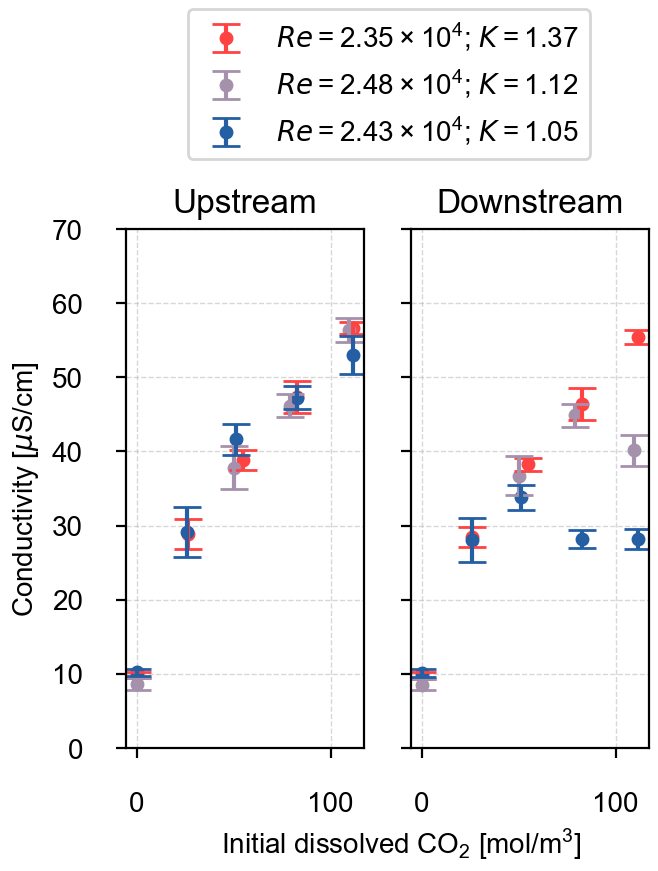

In [46]:
# Figure for conductivity upstream and downstream vs dissolved CO2 concentration

figsize = [3.37 ,3.37 ] # 1 column figure
matplotlib.rcParams['figure.figsize'] = figsize # 1 column figure

cond_lim = 0, 70

# plt_exp = 0, 1, 2, 3, 9, 4 # degas - no cav. with check for contamination
# plt_exp1 = 0, 1, 2, 3, 9 # degas - no cav.
# table_caption1 = "Conductivity statistics for degassed experiments without cavitation."
# plt_exp2 = 5, 6, 7, 8, 13 # dis gas - no cav.
# table_caption2 = "Conductivity statistics for high dissolved CO2 experiments without cavitation."
plt_exp3 = 9, 10, 11, 12, 13 # K = 1.37
plt_col3 = (1, 0.26, 0.26)
plt_exp4 = 14, 15, 16, 17 # K = 1.12
plt_col4 = (0.65, 0.57, 0.68)
plt_exp5 = 18, 19, 20, 21, 22 # K = 1.06
plt_col5 = (0.14, 0.37, 0.64)

# Assuming that the number of samples are so high so combining the standard deviations without the sample size factor is fine
CavNum_plt3 = []
CavNum_plt3.append(np.mean(CavNum[plt_exp3, 0]))
CavNum_plt3.append(np.sqrt(np.sum(CavNum[plt_exp3, 1]**2)/np.size(plt_exp3)))
Re_plt3 = []
Re_plt3.append(np.mean(Re[plt_exp3, 0]))
Re_plt3.append(np.sqrt(np.sum(Re[plt_exp3, 1]**2)/np.size(plt_exp3)))

CavNum_plt4 = []
CavNum_plt4.append(np.mean(CavNum[plt_exp4, 0]))
CavNum_plt4.append(np.sqrt(np.sum(CavNum[plt_exp4, 1]**2)/np.size(plt_exp4)))
Re_plt4 = []
Re_plt4.append(np.mean(Re[plt_exp4, 0]))
Re_plt4.append(np.sqrt(np.sum(Re[plt_exp4, 1]**2)/np.size(plt_exp4)))

CavNum_plt5 = []
CavNum_plt5.append(np.mean(CavNum[plt_exp5, 0]))
CavNum_plt5.append(np.sqrt(np.sum(CavNum[plt_exp5, 1]**2)/np.size(plt_exp5)))
Re_plt5 = []
Re_plt5.append(np.mean(Re[plt_exp5, 0]))
Re_plt5.append(np.sqrt(np.sum(Re[plt_exp5, 1]**2)/np.size(plt_exp5)))

fig, axs = plt.subplots(1, 2)

axs[0].errorbar(co2_conc[plt_exp3, 0], cond_up_stats[plt_exp3, 0], yerr=2*cond_up_stats[plt_exp3, 1], fmt='o', markersize=4, label=f"$Re = {Re_plt3[0]/10**4:.2f} \\times 10^4$; $K = {CavNum_plt3[0]:.2f}$", color=plt_col3, capsize=5, barsabove=True)
axs[0].errorbar(co2_conc[plt_exp4, 0], cond_up_stats[plt_exp4, 0], yerr=2*cond_up_stats[plt_exp4, 1], fmt='o', markersize=4, label=f"$Re = {Re_plt4[0]/10**4:.2f} \\times 10^4$; $K = {CavNum_plt4[0]:.2f}$", color=plt_col4, capsize=5, barsabove=True)
axs[0].errorbar(co2_conc[plt_exp5, 0], cond_up_stats[plt_exp5, 0], yerr=2*cond_up_stats[plt_exp5, 1], fmt='o', markersize=4, label=f"$Re = {Re_plt5[0]/10**4:.2f} \\times 10^4$; $K = {CavNum_plt5[0]:.2f}$", color=plt_col5, capsize=5, barsabove=True)
axs[0].set_xlabel('Initial dissolved CO$_2$ [mol/m$^3$]', loc='left')
axs[0].xaxis.set_label_coords(0.4, -0.15)
axs[0].set_ylabel('Conductivity [$\mu$S/cm]')
axs[0].grid(which='both', linestyle='--', linewidth=0.5, alpha=0.5)
axs[0].legend(loc='upper left', bbox_to_anchor=(0.2, 1.45), frameon=True, ncol=1);
axs[0].set_title("Upstream");
axs[0].set_ylim(cond_lim);


axs[1].errorbar(co2_conc[plt_exp3, 0], cond_down_stats[plt_exp3, 0], yerr=2*cond_down_stats[plt_exp3, 1], fmt='o', markersize=4, label='_Downstream', color=plt_col3, capsize=5, barsabove=True)
axs[1].errorbar(co2_conc[plt_exp4, 0], cond_down_stats[plt_exp4, 0], yerr=2*cond_down_stats[plt_exp4, 1], fmt='o', markersize=4, label='_Downstream', color=plt_col4, capsize=5, barsabove=True)
axs[1].errorbar(co2_conc[plt_exp5, 0], cond_down_stats[plt_exp5, 0], yerr=2*cond_down_stats[plt_exp5, 1], fmt='o', markersize=4, label='_Downstream', color=plt_col5, capsize=5, barsabove=True)
axs[1].tick_params(axis='y', labelleft=False)
axs[1].grid(which='both', linestyle='--', linewidth=0.5, alpha=0.5)
# axs[1].set_xlabel('Initial dissolved CO$_2$ [mol/m$^3$]')
axs[1].set_title("Downstream");
axs[1].set_ylim(cond_lim);

plt.show()


- The upstream conductivity meter readings are used as a control to show that there is no detectable gas release (at least none due to cavitation) in all experiments.
- The downstream conductivity measurements are used to quantify the amount of gas release by interpolating conductivity measurements to the K = 1.37 measurements.
> SG - only the conductivity measurement error (STD) has been propogated with the interpolation.
- There seems to be a relationship between the downstream pressure and the point when the gas release is substantial enough to be noted by a decrease in conductivity.
- The downstream pressure has been normalised using the dissolution pressure which reveals a threshold point at P_CO2 /P_2 ~ 1.5 - 1.8

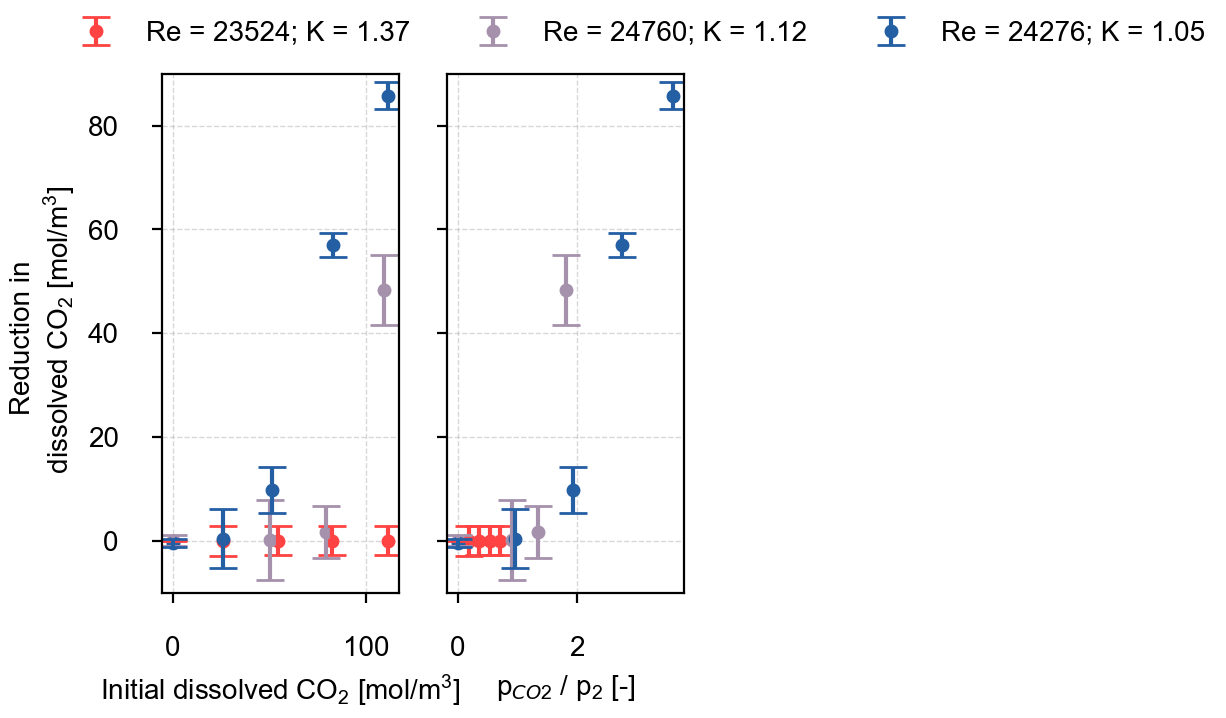

In [71]:
co2_rel_lim = -10, 90

# plt_exp = 0, 1, 2, 3, 9, 4 # degas - no cav. with check for contamination
# plt_exp1 = 0, 1, 2, 3, 9 # degas - no cav.
# table_caption1 = "Conductivity statistics for degassed experiments without cavitation."
# plt_exp2 = 5, 6, 7, 8, 13 # dis gas - no cav.
# table_caption2 = "Conductivity statistics for high dissolved CO2 experiments without cavitation."
plt_exp3 = 9, 10, 11, 12, 13 # K = 1.37
plt_col3 = (1, 0.26, 0.26)
plt_exp4 = 14, 15, 16, 17 # K = 1.12
plt_col4 = (0.65, 0.57, 0.68)
plt_exp5 = 18, 19, 20, 21, 22 # K = 1.06
plt_col5 = (0.14, 0.37, 0.64)

co2_conc_rel = np.zeros_like(co2_conc)
co2_conc_rel[:, 0] = (co2_conc[:, 0] - np.interp(cond_down_stats[:, 0], cond_down_stats[plt_exp3, 0], co2_conc[plt_exp3, 0]))
temp_var =  np.gradient(co2_conc[plt_exp3, 0])/np.gradient(cond_down_stats[plt_exp3, 0])
temp_var = np.interp(cond_down_stats[:, 0], cond_down_stats[plt_exp3, 0], temp_var)
co2_conc_rel[:, 1] = np.sqrt((temp_var*cond_down_stats[:, 1])**2)
co2_conc_rel[plt_exp3, 1] = co2_conc[plt_exp3, 1] # use original uncertainty for calibration points

fig, axs = plt.subplots(1, 2)

axs[0].errorbar(co2_conc[plt_exp3, 0], co2_conc_rel[plt_exp3, 0], yerr=2*co2_conc_rel[plt_exp3, 1], fmt='o', markersize=4, label=f"Re = {Re_plt3[0]:.0f}; K = {CavNum_plt3[0]:.2f}", color=plt_col3, capsize=5, barsabove=True)
axs[0].errorbar(co2_conc[plt_exp4, 0], co2_conc_rel[plt_exp4, 0], yerr=2*co2_conc_rel[plt_exp4, 1], fmt='o', markersize=4, label=f"Re = {Re_plt4[0]:.0f}; K = {CavNum_plt4[0]:.2f}", color=plt_col4, capsize=5, barsabove=True)
axs[0].errorbar(co2_conc[plt_exp5, 0], co2_conc_rel[plt_exp5, 0], yerr=2*co2_conc_rel[plt_exp5, 1], fmt='o', markersize=4, label=f"Re = {Re_plt5[0]:.0f}; K = {CavNum_plt5[0]:.2f}", color=plt_col5, capsize=5, barsabove=True)
axs[0].set_xlabel('Initial dissolved CO$_2$ [mol/m$^3$]')
axs[0].set_ylabel('Reduction in \n dissolved CO$_2$ [mol/m$^3$]')
axs[0].grid(which='both', linestyle='--', linewidth=0.5, alpha=0.5)
axs[0].legend(loc='upper left', bbox_to_anchor=(-0.5, 1.15), frameon=False, ncol=3);
axs[0].set_ylim(co2_rel_lim);

axs[1].errorbar(p3_mean[[plt_exp3]].flatten()/p2_stats[[plt_exp3],0].flatten(), co2_conc_rel[plt_exp3, 0], yerr=2*co2_conc_rel[plt_exp3, 1], fmt='o', markersize=4, label=f"Re = {Re_plt3[0]:.0f}; K = {CavNum_plt3[0]:.2f}", color=plt_col3, capsize=5, barsabove=True)
axs[1].errorbar(p3_mean[[plt_exp4]].flatten()/p2_stats[[plt_exp4],0].flatten(), co2_conc_rel[plt_exp4, 0], yerr=2*co2_conc_rel[plt_exp4, 1], fmt='o', markersize=4, label=f"Re = {Re_plt4[0]:.0f}; K = {CavNum_plt4[0]:.2f}", color=plt_col4, capsize=5, barsabove=True)
axs[1].errorbar(p3_mean[[plt_exp5]].flatten()/p2_stats[[plt_exp5],0].flatten(), co2_conc_rel[plt_exp5, 0], yerr=2*co2_conc_rel[plt_exp5, 1], fmt='o', markersize=4, label=f"Re = {Re_plt5[0]:.0f}; K = {CavNum_plt5[0]:.2f}", color=plt_col5, capsize=5, barsabove=True)
axs[1].tick_params(axis='y', labelleft=False)
axs[1].set_xlabel('p$_{CO2}$ / p$_2$ [-]')
axs[1].grid(which='both', linestyle='--', linewidth=0.5, alpha=0.5)
axs[1].set_ylim(co2_rel_lim);


- The previous plots can be represented as a gas release rate by combining the mean flowrates with the gas release.
- This release rate variable needs to be normalised using some sort of flow/velocity variable and some sort of nozzle geometry based variable.

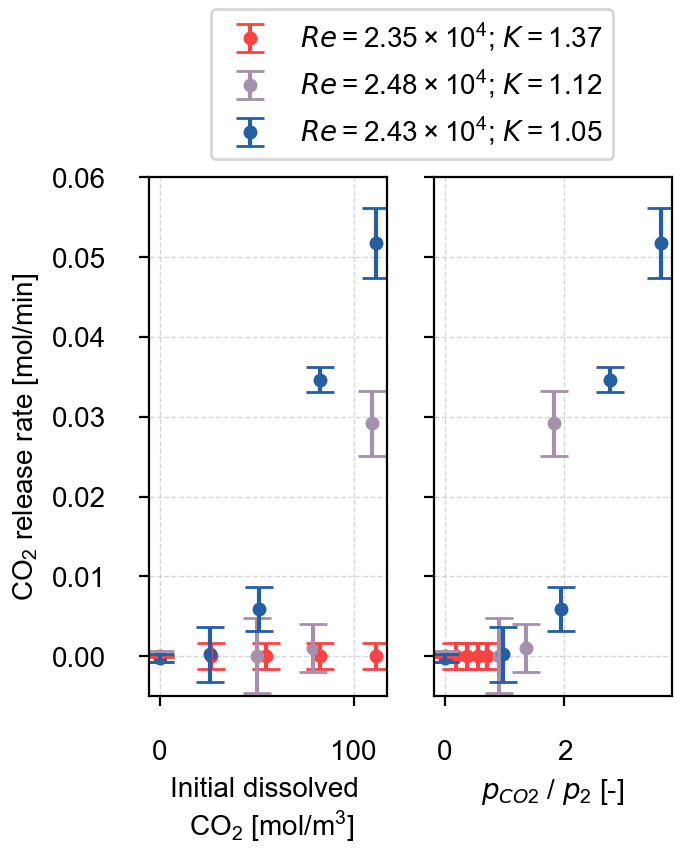

In [80]:
# Figure of CO2 release rate

figsize = [3.37 ,3.37 ] # 1 column figure
matplotlib.rcParams['figure.figsize'] = figsize # 1 column figure

co2_rel_rate_lim = -0.005, 0.06

# plt_exp = 0, 1, 2, 3, 9, 4 # degas - no cav. with check for contamination
# plt_exp1 = 0, 1, 2, 3, 9 # degas - no cav.
# table_caption1 = "Conductivity statistics for degassed experiments without cavitation."
# plt_exp2 = 5, 6, 7, 8, 13 # dis gas - no cav.
# table_caption2 = "Conductivity statistics for high dissolved CO2 experiments without cavitation."
plt_exp3 = 9, 10, 11, 12, 13 # K = 1.37
plt_col3 = (1, 0.26, 0.26)
plt_exp4 = 14, 15, 16, 17 # K = 1.12
plt_col4 = (0.65, 0.57, 0.68)
plt_exp5 = 18, 19, 20, 21, 22 # K = 1.06
plt_col5 = (0.14, 0.37, 0.64)

co2_conc_rel_rate = np.zeros_like(co2_conc)
co2_conc_rel_rate[:, 0] = co2_conc_rel[:, 0]*qflow_stats[:, 0] # mol/min
co2_conc_rel_rate[:, 1] = np.sqrt((co2_conc_rel[:, 1]*qflow_stats[:, 0])**2 + (co2_conc_rel[:, 0]*qflow_stats[:, 1])**2) # mol/min

fig, axs = plt.subplots(1, 2)

axs[0].errorbar(co2_conc[plt_exp3, 0], co2_conc_rel_rate[plt_exp3, 0], yerr=2*co2_conc_rel_rate[plt_exp3, 1], fmt='o', markersize=4, label=f"$Re = {Re_plt3[0]/10**4:.2f} \\times 10^4$; $K = {CavNum_plt3[0]:.2f}$", color=plt_col3, capsize=5, barsabove=True)
axs[0].errorbar(co2_conc[plt_exp4, 0], co2_conc_rel_rate[plt_exp4, 0], yerr=2*co2_conc_rel_rate[plt_exp4, 1], fmt='o', markersize=4, label=f"$Re = {Re_plt4[0]/10**4:.2f} \\times 10^4$; $K = {CavNum_plt4[0]:.2f}$", color=plt_col4, capsize=5, barsabove=True)
axs[0].errorbar(co2_conc[plt_exp5, 0], co2_conc_rel_rate[plt_exp5, 0], yerr=2*co2_conc_rel_rate[plt_exp5, 1], fmt='o', markersize=4, label=f"$Re = {Re_plt5[0]/10**4:.2f} \\times 10^4$; $K = {CavNum_plt5[0]:.2f}$", color=plt_col5, capsize=5, barsabove=True)
axs[0].set_xlabel('Initial dissolved \n CO$_2$ [mol/m$^3$]')
axs[0].set_ylabel('CO$_2$ release rate [mol/min]')
axs[0].grid(which='both', linestyle='--', linewidth=0.5, alpha=0.5)
axs[0].legend(loc='upper left', bbox_to_anchor=(0.2, 1.35), frameon=True, ncol=1);
axs[0].set_ylim(co2_rel_rate_lim);

axs[1].errorbar(p3_mean[[plt_exp3]].flatten()/p2_stats[[plt_exp3],0].flatten(), co2_conc_rel_rate[plt_exp3, 0], yerr=2*co2_conc_rel_rate[plt_exp3, 1], fmt='o', markersize=4, label=f"Re = {Re_plt3[0]:.0f}; K = {CavNum_plt3[0]:.2f}", color=plt_col3, capsize=5, barsabove=True)
axs[1].errorbar(p3_mean[[plt_exp4]].flatten()/p2_stats[[plt_exp4],0].flatten(), co2_conc_rel_rate[plt_exp4, 0], yerr=2*co2_conc_rel_rate[plt_exp4, 1], fmt='o', markersize=4, label=f"Re = {Re_plt4[0]:.0f}; K = {CavNum_plt4[0]:.2f}", color=plt_col4, capsize=5, barsabove=True)
axs[1].errorbar(p3_mean[[plt_exp5]].flatten()/p2_stats[[plt_exp5],0].flatten(), co2_conc_rel_rate[plt_exp5, 0], yerr=2*co2_conc_rel_rate[plt_exp5, 1], fmt='o', markersize=4, label=f"Re = {Re_plt5[0]:.0f}; K = {CavNum_plt5[0]:.2f}", color=plt_col5, capsize=5, barsabove=True)
axs[1].tick_params(axis='y', labelleft=False)
axs[1].set_xlabel('$p_{CO2}$ / $p_2$ [-]')
axs[1].grid(which='both', linestyle='--', linewidth=0.5, alpha=0.5)
axs[1].set_ylim(co2_rel_rate_lim);

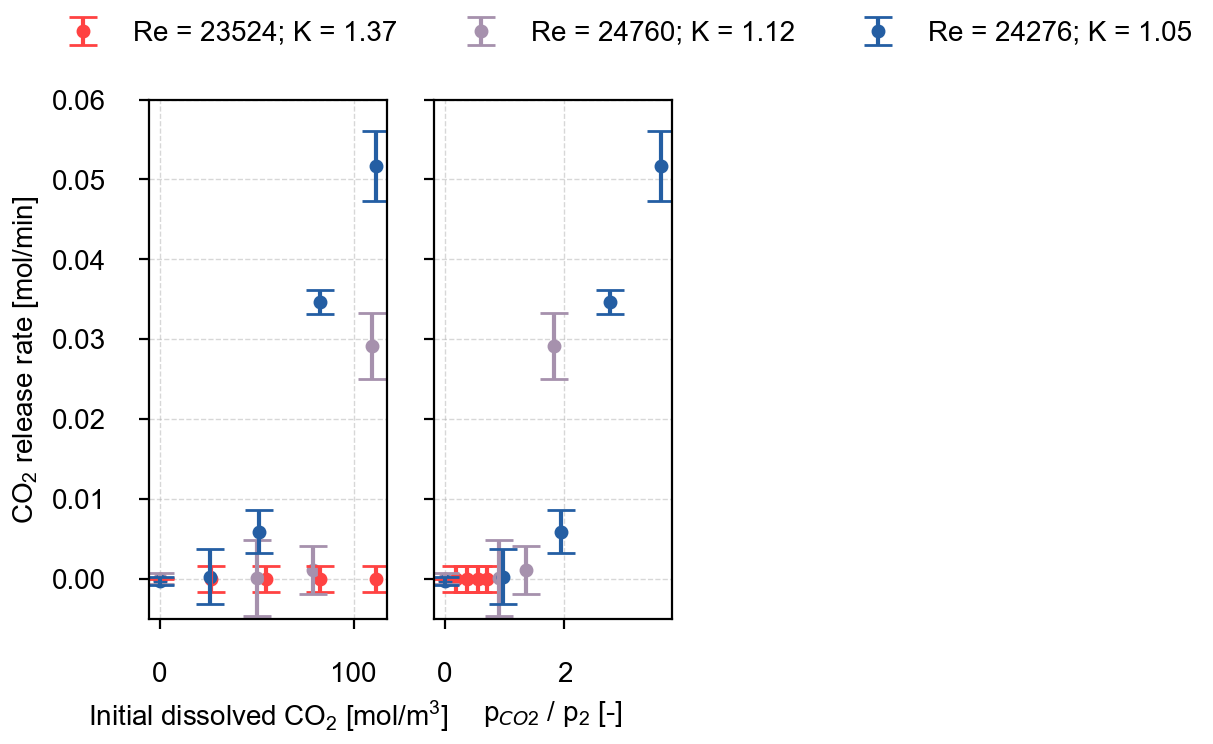

In [81]:
co2_rel_rate_lim = -0.005, 0.06

# plt_exp = 0, 1, 2, 3, 9, 4 # degas - no cav. with check for contamination
# plt_exp1 = 0, 1, 2, 3, 9 # degas - no cav.
# table_caption1 = "Conductivity statistics for degassed experiments without cavitation."
# plt_exp2 = 5, 6, 7, 8, 13 # dis gas - no cav.
# table_caption2 = "Conductivity statistics for high dissolved CO2 experiments without cavitation."
plt_exp3 = 9, 10, 11, 12, 13 # K = 1.37
plt_col3 = (1, 0.26, 0.26)
plt_exp4 = 14, 15, 16, 17 # K = 1.12
plt_col4 = (0.65, 0.57, 0.68)
plt_exp5 = 18, 19, 20, 21, 22 # K = 1.06
plt_col5 = (0.14, 0.37, 0.64)

co2_conc_rel_rate = np.zeros_like(co2_conc)
co2_conc_rel_rate[:, 0] = co2_conc_rel[:, 0]*qflow_stats[:, 0] # mol/min
co2_conc_rel_rate[:, 1] = np.sqrt((co2_conc_rel[:, 1]*qflow_stats[:, 0])**2 + (co2_conc_rel[:, 0]*qflow_stats[:, 1])**2) # mol/min

fig, axs = plt.subplots(1, 2)

axs[0].errorbar(co2_conc[plt_exp3, 0], co2_conc_rel_rate[plt_exp3, 0], yerr=2*co2_conc_rel_rate[plt_exp3, 1], fmt='o', markersize=4, label=f"Re = {Re_plt3[0]:.0f}; K = {CavNum_plt3[0]:.2f}", color=plt_col3, capsize=5, barsabove=True)
axs[0].errorbar(co2_conc[plt_exp4, 0], co2_conc_rel_rate[plt_exp4, 0], yerr=2*co2_conc_rel_rate[plt_exp4, 1], fmt='o', markersize=4, label=f"Re = {Re_plt4[0]:.0f}; K = {CavNum_plt4[0]:.2f}", color=plt_col4, capsize=5, barsabove=True)
axs[0].errorbar(co2_conc[plt_exp5, 0], co2_conc_rel_rate[plt_exp5, 0], yerr=2*co2_conc_rel_rate[plt_exp5, 1], fmt='o', markersize=4, label=f"Re = {Re_plt5[0]:.0f}; K = {CavNum_plt5[0]:.2f}", color=plt_col5, capsize=5, barsabove=True)
axs[0].set_xlabel('Initial dissolved CO$_2$ [mol/m$^3$]')
axs[0].set_ylabel('CO$_2$ release rate [mol/min]')
axs[0].grid(which='both', linestyle='--', linewidth=0.5, alpha=0.5)
axs[0].legend(loc='upper left', bbox_to_anchor=(-0.5, 1.2), frameon=False, ncol=3);
axs[0].set_ylim(co2_rel_rate_lim);

axs[1].errorbar(p3_mean[[plt_exp3]].flatten()/p2_stats[[plt_exp3],0].flatten(), co2_conc_rel_rate[plt_exp3, 0], yerr=2*co2_conc_rel_rate[plt_exp3, 1], fmt='o', markersize=4, label=f"Re = {Re_plt3[0]:.0f}; K = {CavNum_plt3[0]:.2f}", color=plt_col3, capsize=5, barsabove=True)
axs[1].errorbar(p3_mean[[plt_exp4]].flatten()/p2_stats[[plt_exp4],0].flatten(), co2_conc_rel_rate[plt_exp4, 0], yerr=2*co2_conc_rel_rate[plt_exp4, 1], fmt='o', markersize=4, label=f"Re = {Re_plt4[0]:.0f}; K = {CavNum_plt4[0]:.2f}", color=plt_col4, capsize=5, barsabove=True)
axs[1].errorbar(p3_mean[[plt_exp5]].flatten()/p2_stats[[plt_exp5],0].flatten(), co2_conc_rel_rate[plt_exp5, 0], yerr=2*co2_conc_rel_rate[plt_exp5, 1], fmt='o', markersize=4, label=f"Re = {Re_plt5[0]:.0f}; K = {CavNum_plt5[0]:.2f}", color=plt_col5, capsize=5, barsabove=True)
axs[1].tick_params(axis='y', labelleft=False)
axs[1].set_xlabel('p$_{CO2}$ / p$_2$ [-]')
axs[1].grid(which='both', linestyle='--', linewidth=0.5, alpha=0.5)
axs[1].set_ylim(co2_rel_rate_lim);

#### Gas release efficiency

- First comparing the gas release rate to mass flow rate.

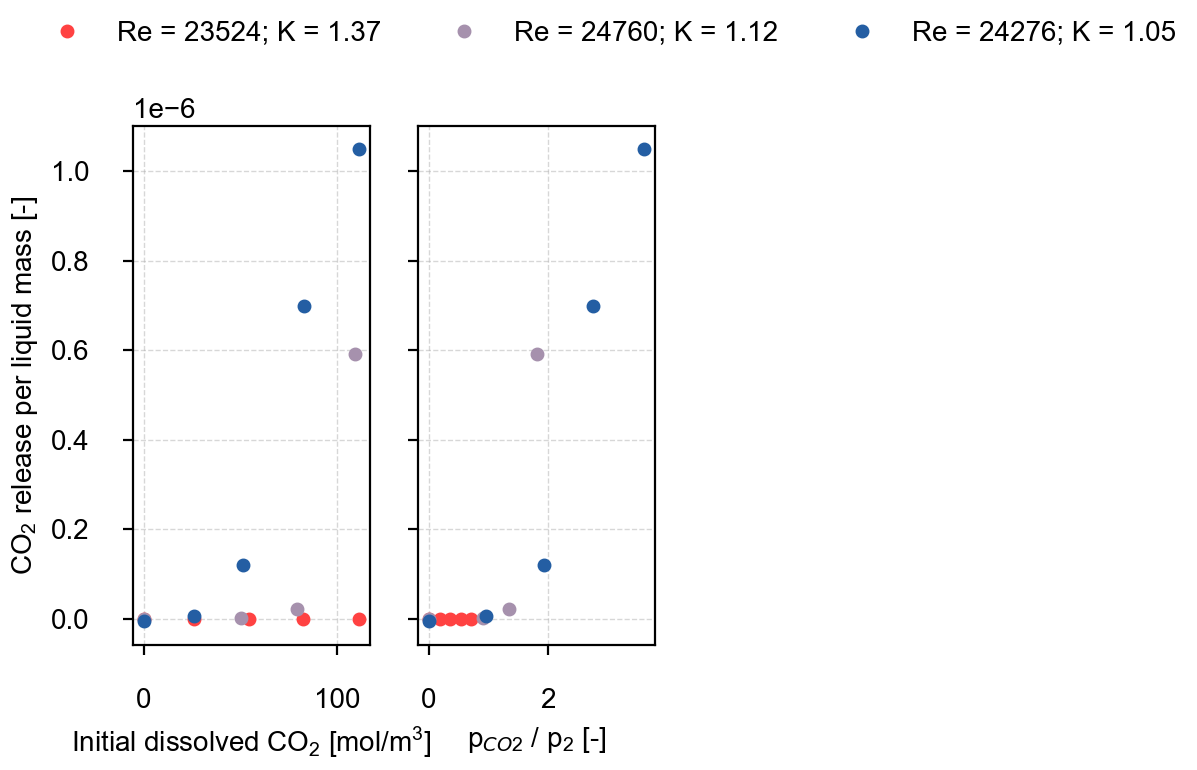

In [82]:
# co2_rel_rate_lim = -0.005, 0.06

# plt_exp = 0, 1, 2, 3, 9, 4 # degas - no cav. with check for contamination
# plt_exp1 = 0, 1, 2, 3, 9 # degas - no cav.
# table_caption1 = "Conductivity statistics for degassed experiments without cavitation."
# plt_exp2 = 5, 6, 7, 8, 13 # dis gas - no cav.
# table_caption2 = "Conductivity statistics for high dissolved CO2 experiments without cavitation."
plt_exp3 = 9, 10, 11, 12, 13 # K = 1.37
plt_col3 = (1, 0.26, 0.26)
plt_exp4 = 14, 15, 16, 17 # K = 1.12
plt_col4 = (0.65, 0.57, 0.68)
plt_exp5 = 18, 19, 20, 21, 22 # K = 1.06
plt_col5 = (0.14, 0.37, 0.64)

# CP.PropsSI('D', 'T', 293.15, 'P', 14.7*6895, 'CO2')
co2_molemass = CP.PropsSI('CO2', 'molemass') # kg/mol
co2_mass_rel_rate = co2_conc_rel_rate*co2_molemass/60 # kg/s
co2_rel_per_mass = co2_mass_rel_rate/(qflow_stats*(dens1*60))

fig, axs = plt.subplots(1, 2)

# axs[0].errorbar(co2_conc[plt_exp3, 0], co2_mass_rel_rate[plt_exp3, 0]/(qflow_stats[plt_exp3,0]*(dens1[plt_exp3,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp3, 1], fmt='o', markersize=4, label=f"Re = {Re_plt3[0]:.0f}; K = {CavNum_plt3[0]:.2f}", color=plt_col3, capsize=5, barsabove=True)
# axs[0].errorbar(co2_conc[plt_exp4, 0], co2_mass_rel_rate[plt_exp4, 0]/(qflow_stats[plt_exp4,0]*(dens1[plt_exp4,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp4, 1], fmt='o', markersize=4, label=f"Re = {Re_plt4[0]:.0f}; K = {CavNum_plt4[0]:.2f}", color=plt_col4, capsize=5, barsabove=True)
# axs[0].errorbar(co2_conc[plt_exp5, 0], co2_mass_rel_rate[plt_exp5, 0]/(qflow_stats[plt_exp5,0]*(dens1[plt_exp5,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp5, 1], fmt='o', markersize=4, label=f"Re = {Re_plt5[0]:.0f}; K = {CavNum_plt5[0]:.2f}", color=plt_col5, capsize=5, barsabove=True)
axs[0].errorbar(co2_conc[plt_exp3, 0], co2_rel_per_mass[plt_exp3, 0], fmt='o', markersize=4, label=f"Re = {Re_plt3[0]:.0f}; K = {CavNum_plt3[0]:.2f}", color=plt_col3, capsize=5, barsabove=True)
axs[0].errorbar(co2_conc[plt_exp4, 0], co2_rel_per_mass[plt_exp4, 0], fmt='o', markersize=4, label=f"Re = {Re_plt4[0]:.0f}; K = {CavNum_plt4[0]:.2f}", color=plt_col4, capsize=5, barsabove=True)
axs[0].errorbar(co2_conc[plt_exp5, 0], co2_rel_per_mass[plt_exp5, 0], fmt='o', markersize=4, label=f"Re = {Re_plt5[0]:.0f}; K = {CavNum_plt5[0]:.2f}", color=plt_col5, capsize=5, barsabove=True)
axs[0].set_xlabel('Initial dissolved CO$_2$ [mol/m$^3$]')
axs[0].set_ylabel('CO$_2$ release per liquid mass [-]')
axs[0].grid(which='both', linestyle='--', linewidth=0.5, alpha=0.5)
axs[0].legend(loc='upper left', bbox_to_anchor=(-0.5, 1.25), frameon=False, ncol=3);
# axs[0].set_ylim(co2_rel_rate_lim);

# axs[1].errorbar(p3_mean[[plt_exp3]].flatten()/p2_stats[[plt_exp3],0].flatten(), co2_mass_rel_rate[plt_exp3, 0]/(qflow_stats[plt_exp3,0]*(dens1[plt_exp3,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp3, 1], fmt='o', markersize=4, label=f"Re = {Re_plt3[0]:.0f}; K = {CavNum_plt3[0]:.2f}", color=plt_col3, capsize=5, barsabove=True)
# axs[1].errorbar(p3_mean[[plt_exp4]].flatten()/p2_stats[[plt_exp4],0].flatten(), co2_mass_rel_rate[plt_exp4, 0]/(qflow_stats[plt_exp4,0]*(dens1[plt_exp4,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp4, 1], fmt='o', markersize=4, label=f"Re = {Re_plt4[0]:.0f}; K = {CavNum_plt4[0]:.2f}", color=plt_col4, capsize=5, barsabove=True)
# axs[1].errorbar(p3_mean[[plt_exp5]].flatten()/p2_stats[[plt_exp5],0].flatten(), co2_mass_rel_rate[plt_exp5, 0]/(qflow_stats[plt_exp5,0]*(dens1[plt_exp5,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp5, 1], fmt='o', markersize=4, label=f"Re = {Re_plt5[0]:.0f}; K = {CavNum_plt5[0]:.2f}", color=plt_col5, capsize=5, barsabove=True)
axs[1].errorbar(p3_mean[[plt_exp3]].flatten()/p2_stats[[plt_exp3],0].flatten(), co2_rel_per_mass[plt_exp3, 0], fmt='o', markersize=4, label=f"Re = {Re_plt3[0]:.0f}; K = {CavNum_plt3[0]:.2f}", color=plt_col3, capsize=5, barsabove=True)
axs[1].errorbar(p3_mean[[plt_exp4]].flatten()/p2_stats[[plt_exp4],0].flatten(), co2_rel_per_mass[plt_exp4, 0], fmt='o', markersize=4, label=f"Re = {Re_plt4[0]:.0f}; K = {CavNum_plt4[0]:.2f}", color=plt_col4, capsize=5, barsabove=True)
axs[1].errorbar(p3_mean[[plt_exp5]].flatten()/p2_stats[[plt_exp5],0].flatten(), co2_rel_per_mass[plt_exp5, 0], fmt='o', markersize=4, label=f"Re = {Re_plt5[0]:.0f}; K = {CavNum_plt5[0]:.2f}", color=plt_col5, capsize=5, barsabove=True)
axs[1].tick_params(axis='y', labelleft=False)
axs[1].set_xlabel('p$_{CO2}$ / p$_2$ [-]')
axs[1].grid(which='both', linestyle='--', linewidth=0.5, alpha=0.5)
# axs[1].set_ylim(co2_rel_rate_lim);

- Comparing the pumping work per gas release

C:\Users\sgun0045\AppData\Local\Temp\ipykernel_111308\1107682491.py:17: RuntimeWarning: divide by zero encountered in divide
  co2_rel_per_pump_work = (delp_stats/dens1) / co2_rel_per_mass


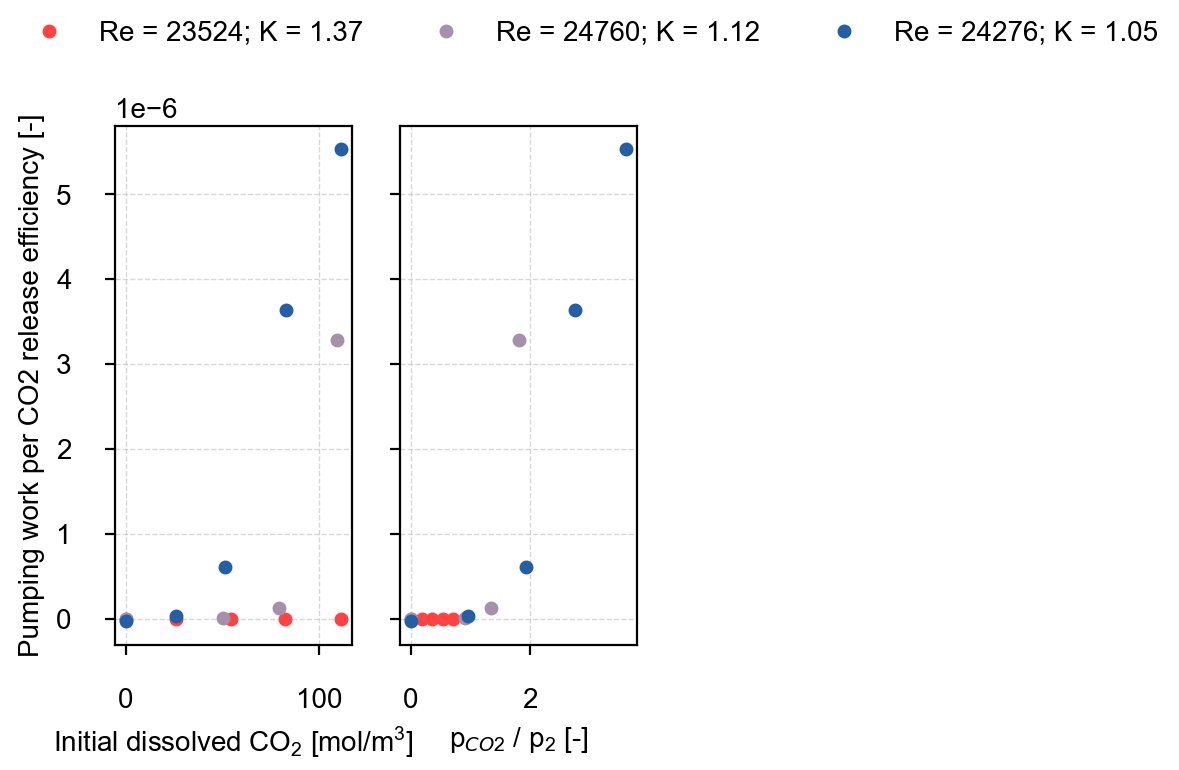

In [83]:
# co2_rel_rate_lim = -0.005, 0.06

# plt_exp = 0, 1, 2, 3, 9, 4 # degas - no cav. with check for contamination
# plt_exp1 = 0, 1, 2, 3, 9 # degas - no cav.
# table_caption1 = "Conductivity statistics for degassed experiments without cavitation."
# plt_exp2 = 5, 6, 7, 8, 13 # dis gas - no cav.
# table_caption2 = "Conductivity statistics for high dissolved CO2 experiments without cavitation."
plt_exp3 = 9, 10, 11, 12, 13 # K = 1.37
plt_col3 = (1, 0.26, 0.26)
plt_exp4 = 14, 15, 16, 17 # K = 1.12
plt_col4 = (0.65, 0.57, 0.68)
plt_exp5 = 18, 19, 20, 21, 22 # K = 1.06
plt_col5 = (0.14, 0.37, 0.64)

# CP.PropsSI('D', 'T', 293.15, 'P', 14.7*6895, 'CO2')
co2_rel_per_mass = co2_mass_rel_rate/(qflow_stats*(dens1*60))
co2_rel_per_pump_work = (delp_stats/dens1) / co2_rel_per_mass
co2_rel_per_pump_work =  co2_rel_per_mass /(delp_stats/dens1) 


fig, axs = plt.subplots(1, 2)

# axs[0].errorbar(co2_conc[plt_exp3, 0], co2_mass_rel_rate[plt_exp3, 0]/(qflow_stats[plt_exp3,0]*(dens1[plt_exp3,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp3, 1], fmt='o', markersize=4, label=f"Re = {Re_plt3[0]:.0f}; K = {CavNum_plt3[0]:.2f}", color=plt_col3, capsize=5, barsabove=True)
# axs[0].errorbar(co2_conc[plt_exp4, 0], co2_mass_rel_rate[plt_exp4, 0]/(qflow_stats[plt_exp4,0]*(dens1[plt_exp4,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp4, 1], fmt='o', markersize=4, label=f"Re = {Re_plt4[0]:.0f}; K = {CavNum_plt4[0]:.2f}", color=plt_col4, capsize=5, barsabove=True)
# axs[0].errorbar(co2_conc[plt_exp5, 0], co2_mass_rel_rate[plt_exp5, 0]/(qflow_stats[plt_exp5,0]*(dens1[plt_exp5,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp5, 1], fmt='o', markersize=4, label=f"Re = {Re_plt5[0]:.0f}; K = {CavNum_plt5[0]:.2f}", color=plt_col5, capsize=5, barsabove=True)
# axs[0].errorbar(co2_conc[plt_exp3, 0], delp_stats[plt_exp3, 0]/dens1[plt_exp3,0], fmt='o', markersize=4, label=f"Re = {Re_plt3[0]:.0f}; K = {CavNum_plt3[0]:.2f}", color=plt_col3, capsize=5, barsabove=True)
# axs[0].errorbar(co2_conc[plt_exp4, 0], delp_stats[plt_exp4, 0]/dens1[plt_exp4,0], fmt='o', markersize=4, label=f"Re = {Re_plt4[0]:.0f}; K = {CavNum_plt4[0]:.2f}", color=plt_col4, capsize=5, barsabove=True)
# axs[0].errorbar(co2_conc[plt_exp5, 0], delp_stats[plt_exp5, 0]/dens1[plt_exp5,0], fmt='o', markersize=4, label=f"Re = {Re_plt5[0]:.0f}; K = {CavNum_plt5[0]:.2f}", color=plt_col5, capsize=5, barsabove=True)
axs[0].errorbar(co2_conc[plt_exp3, 0], co2_rel_per_pump_work[plt_exp3, 0], fmt='o', markersize=4, label=f"Re = {Re_plt3[0]:.0f}; K = {CavNum_plt3[0]:.2f}", color=plt_col3, capsize=5, barsabove=True)
axs[0].errorbar(co2_conc[plt_exp4, 0], co2_rel_per_pump_work[plt_exp4, 0], fmt='o', markersize=4, label=f"Re = {Re_plt4[0]:.0f}; K = {CavNum_plt4[0]:.2f}", color=plt_col4, capsize=5, barsabove=True)
axs[0].errorbar(co2_conc[plt_exp5, 0], co2_rel_per_pump_work[plt_exp5, 0], fmt='o', markersize=4, label=f"Re = {Re_plt5[0]:.0f}; K = {CavNum_plt5[0]:.2f}", color=plt_col5, capsize=5, barsabove=True)

axs[0].set_xlabel('Initial dissolved CO$_2$ [mol/m$^3$]')
axs[0].set_ylabel('Pumping work per CO2 release efficiency [-]')
axs[0].grid(which='both', linestyle='--', linewidth=0.5, alpha=0.5)
axs[0].legend(loc='upper left', bbox_to_anchor=(-0.5, 1.25), frameon=False, ncol=3);
# axs[0].set_ylim(co2_rel_rate_lim);

# axs[1].errorbar(p3_mean[[plt_exp3]].flatten()/p2_stats[[plt_exp3],0].flatten(), co2_mass_rel_rate[plt_exp3, 0]/(qflow_stats[plt_exp3,0]*(dens1[plt_exp3,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp3, 1], fmt='o', markersize=4, label=f"Re = {Re_plt3[0]:.0f}; K = {CavNum_plt3[0]:.2f}", color=plt_col3, capsize=5, barsabove=True)
# axs[1].errorbar(p3_mean[[plt_exp4]].flatten()/p2_stats[[plt_exp4],0].flatten(), co2_mass_rel_rate[plt_exp4, 0]/(qflow_stats[plt_exp4,0]*(dens1[plt_exp4,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp4, 1], fmt='o', markersize=4, label=f"Re = {Re_plt4[0]:.0f}; K = {CavNum_plt4[0]:.2f}", color=plt_col4, capsize=5, barsabove=True)
# axs[1].errorbar(p3_mean[[plt_exp5]].flatten()/p2_stats[[plt_exp5],0].flatten(), co2_mass_rel_rate[plt_exp5, 0]/(qflow_stats[plt_exp5,0]*(dens1[plt_exp5,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp5, 1], fmt='o', markersize=4, label=f"Re = {Re_plt5[0]:.0f}; K = {CavNum_plt5[0]:.2f}", color=plt_col5, capsize=5, barsabove=True)
axs[1].errorbar(p3_mean[[plt_exp3]].flatten()/p2_stats[[plt_exp3],0].flatten(), co2_rel_per_pump_work[plt_exp3, 0], fmt='o', markersize=4, label=f"Re = {Re_plt3[0]:.0f}; K = {CavNum_plt3[0]:.2f}", color=plt_col3, capsize=5, barsabove=True)
axs[1].errorbar(p3_mean[[plt_exp4]].flatten()/p2_stats[[plt_exp4],0].flatten(), co2_rel_per_pump_work[plt_exp4, 0], fmt='o', markersize=4, label=f"Re = {Re_plt4[0]:.0f}; K = {CavNum_plt4[0]:.2f}", color=plt_col4, capsize=5, barsabove=True)
axs[1].errorbar(p3_mean[[plt_exp5]].flatten()/p2_stats[[plt_exp5],0].flatten(), co2_rel_per_pump_work[plt_exp5, 0], fmt='o', markersize=4, label=f"Re = {Re_plt5[0]:.0f}; K = {CavNum_plt5[0]:.2f}", color=plt_col5, capsize=5, barsabove=True)
axs[1].tick_params(axis='y', labelleft=False)
axs[1].set_xlabel('p$_{CO2}$ / p$_2$ [-]')
axs[1].grid(which='both', linestyle='--', linewidth=0.5, alpha=0.5)
# axs[1].set_ylim(co2_rel_rate_lim);

- Comparing the pumping power per gas release using GJ/ton-CO2
    - Need to check which ton is used in these CO2 capture measurements (metric tonne, short ton, long/imperial ton). Currently using short ton

C:\Users\sgun0045\AppData\Local\Temp\ipykernel_111308\1053909630.py:24: RuntimeWarning: divide by zero encountered in divide
  co2_rel_efficiency = pump_power / co2_mass_rel_rate_ton # GJ / ton-CO2


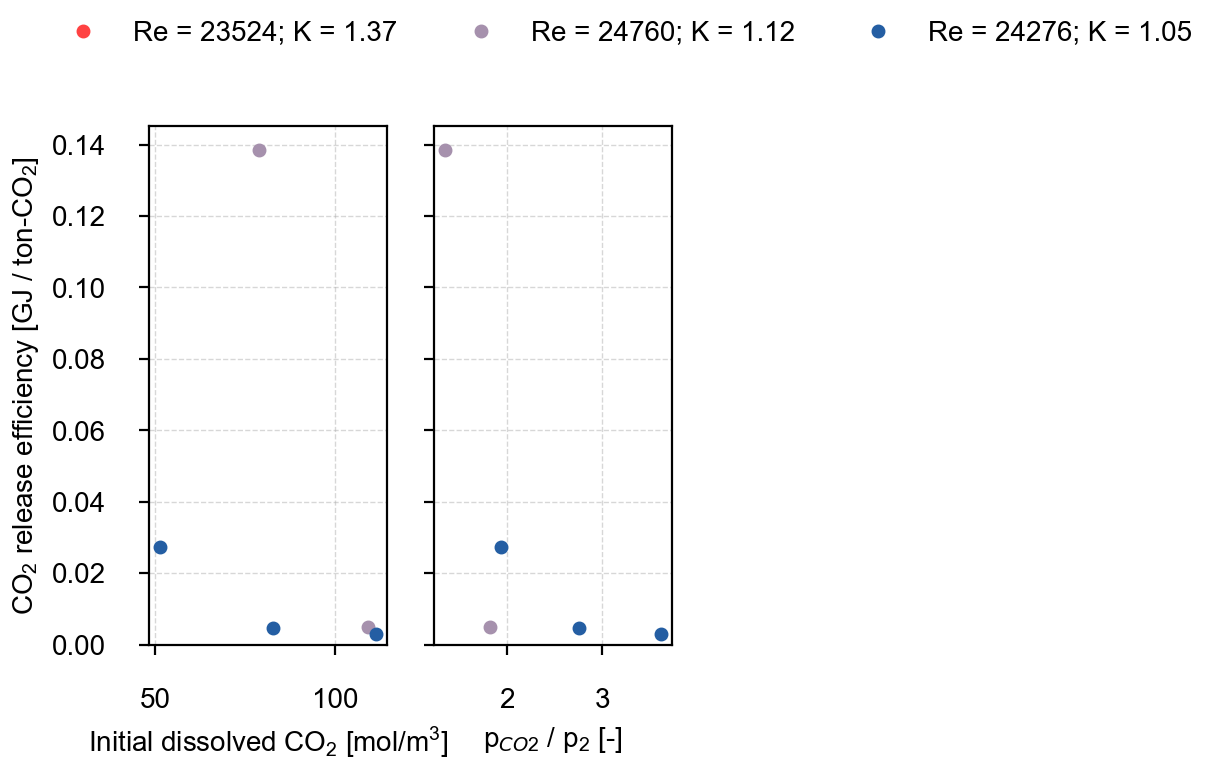

In [84]:
# co2_rel_rate_lim = -0.005, 0.06

# plt_exp = 0, 1, 2, 3, 9, 4 # degas - no cav. with check for contamination
# plt_exp1 = 0, 1, 2, 3, 9 # degas - no cav.
# table_caption1 = "Conductivity statistics for degassed experiments without cavitation."
# plt_exp2 = 5, 6, 7, 8, 13 # dis gas - no cav.
# table_caption2 = "Conductivity statistics for high dissolved CO2 experiments without cavitation."
plt_exp3 = 9, 10, 11, 12, 13 # K = 1.37
plt_col3 = (1, 0.26, 0.26)
# plt_exp4 = 14, 15, 16, 17 # K = 1.12
plt_exp4 = 16, 17 # K = 1.12
plt_col4 = (0.65, 0.57, 0.68)
# plt_exp5 = 18, 19, 20, 21, 22 # K = 1.06
plt_exp5 = 20, 21, 22 # K = 1.06
plt_col5 = (0.14, 0.37, 0.64)

# CP.PropsSI('D', 'T', 293.15, 'P', 14.7*6895, 'CO2')
co2_molemass = CP.PropsSI('CO2', 'molemass') # kg/mol
co2_mass_rel_rate = co2_conc_rel_rate * co2_molemass/60 # kg/s
co2_mass_rel_rate_ton = co2_mass_rel_rate*0.001 # Mt/s

pump_power = delp_stats * qflow_stats / 10**9 # GW

co2_rel_efficiency = pump_power / co2_mass_rel_rate_ton # GJ / ton-CO2

fig, axs = plt.subplots(1, 2)

# axs[0].errorbar(co2_conc[plt_exp3, 0], co2_mass_rel_rate[plt_exp3, 0]/(qflow_stats[plt_exp3,0]*(dens1[plt_exp3,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp3, 1], fmt='o', markersize=4, label=f"Re = {Re_plt3[0]:.0f}; K = {CavNum_plt3[0]:.2f}", color=plt_col3, capsize=5, barsabove=True)
# axs[0].errorbar(co2_conc[plt_exp4, 0], co2_mass_rel_rate[plt_exp4, 0]/(qflow_stats[plt_exp4,0]*(dens1[plt_exp4,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp4, 1], fmt='o', markersize=4, label=f"Re = {Re_plt4[0]:.0f}; K = {CavNum_plt4[0]:.2f}", color=plt_col4, capsize=5, barsabove=True)
# axs[0].errorbar(co2_conc[plt_exp5, 0], co2_mass_rel_rate[plt_exp5, 0]/(qflow_stats[plt_exp5,0]*(dens1[plt_exp5,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp5, 1], fmt='o', markersize=4, label=f"Re = {Re_plt5[0]:.0f}; K = {CavNum_plt5[0]:.2f}", color=plt_col5, capsize=5, barsabove=True)
axs[0].errorbar(co2_conc[plt_exp3, 0], co2_rel_efficiency[plt_exp3, 0], fmt='o', markersize=4, label=f"Re = {Re_plt3[0]:.0f}; K = {CavNum_plt3[0]:.2f}", color=plt_col3, capsize=5, barsabove=True)
axs[0].errorbar(co2_conc[plt_exp4, 0], co2_rel_efficiency[plt_exp4, 0], fmt='o', markersize=4, label=f"Re = {Re_plt4[0]:.0f}; K = {CavNum_plt4[0]:.2f}", color=plt_col4, capsize=5, barsabove=True)
axs[0].errorbar(co2_conc[plt_exp5, 0], co2_rel_efficiency[plt_exp5, 0], fmt='o', markersize=4, label=f"Re = {Re_plt5[0]:.0f}; K = {CavNum_plt5[0]:.2f}", color=plt_col5, capsize=5, barsabove=True)
axs[0].set_xlabel('Initial dissolved CO$_2$ [mol/m$^3$]')
axs[0].set_ylabel('CO$_2$ release efficiency [GJ / ton-CO$_2$]')
axs[0].grid(which='both', linestyle='--', linewidth=0.5, alpha=0.5)
axs[0].legend(loc='upper left', bbox_to_anchor=(-0.5, 1.25), frameon=False, ncol=3);
# axs[0].set_ylim(co2_rel_rate_lim);
axs[0].set_ylim(0, );

# axs[1].errorbar(p3_mean[[plt_exp3]].flatten()/p2_stats[[plt_exp3],0].flatten(), co2_mass_rel_rate[plt_exp3, 0]/(qflow_stats[plt_exp3,0]*(dens1[plt_exp3,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp3, 1], fmt='o', markersize=4, label=f"Re = {Re_plt3[0]:.0f}; K = {CavNum_plt3[0]:.2f}", color=plt_col3, capsize=5, barsabove=True)
# axs[1].errorbar(p3_mean[[plt_exp4]].flatten()/p2_stats[[plt_exp4],0].flatten(), co2_mass_rel_rate[plt_exp4, 0]/(qflow_stats[plt_exp4,0]*(dens1[plt_exp4,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp4, 1], fmt='o', markersize=4, label=f"Re = {Re_plt4[0]:.0f}; K = {CavNum_plt4[0]:.2f}", color=plt_col4, capsize=5, barsabove=True)
# axs[1].errorbar(p3_mean[[plt_exp5]].flatten()/p2_stats[[plt_exp5],0].flatten(), co2_mass_rel_rate[plt_exp5, 0]/(qflow_stats[plt_exp5,0]*(dens1[plt_exp5,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp5, 1], fmt='o', markersize=4, label=f"Re = {Re_plt5[0]:.0f}; K = {CavNum_plt5[0]:.2f}", color=plt_col5, capsize=5, barsabove=True)
axs[1].errorbar(p3_mean[[plt_exp3]].flatten()/p2_stats[[plt_exp3],0].flatten(), co2_rel_efficiency[plt_exp3, 0], fmt='o', markersize=4, label=f"Re = {Re_plt3[0]:.0f}; K = {CavNum_plt3[0]:.2f}", color=plt_col3, capsize=5, barsabove=True)
axs[1].errorbar(p3_mean[[plt_exp4]].flatten()/p2_stats[[plt_exp4],0].flatten(), co2_rel_efficiency[plt_exp4, 0], fmt='o', markersize=4, label=f"Re = {Re_plt4[0]:.0f}; K = {CavNum_plt4[0]:.2f}", color=plt_col4, capsize=5, barsabove=True)
axs[1].errorbar(p3_mean[[plt_exp5]].flatten()/p2_stats[[plt_exp5],0].flatten(), co2_rel_efficiency[plt_exp5, 0], fmt='o', markersize=4, label=f"Re = {Re_plt5[0]:.0f}; K = {CavNum_plt5[0]:.2f}", color=plt_col5, capsize=5, barsabove=True)
axs[1].tick_params(axis='y', labelleft=False)
axs[1].set_xlabel('p$_{CO2}$ / p$_2$ [-]')
axs[1].grid(which='both', linestyle='--', linewidth=0.5, alpha=0.5)
# axs[1].set_ylim(co2_rel_rate_lim);
axs[1].set_ylim(0, );

Roughly the amine scrubbing / regeneration efficiency of carbon capture systems are somewhere between 3 - 5 GJ / ton CO2 for systems that use MEA. With the use of MDEA and PZ this efficiency keeps decreasing especially in recent years. 

The throughput of carbon capture systems seem to be on average about 1 - 10 mega ton CO2 / year. These are mainly tied to coal and power plants. The smaller onsite systems (potentially tied to cement and other small industries) are of smaller capacity (100s kilo ton CO2 / year capacity).

C:\Users\sgun0045\AppData\Local\Temp\ipykernel_111308\3243704355.py:27: RuntimeWarning: divide by zero encountered in divide
  co2_rel_efficiency = pump_power / co2_mass_rel_rate_ton # GJ / ton-CO2


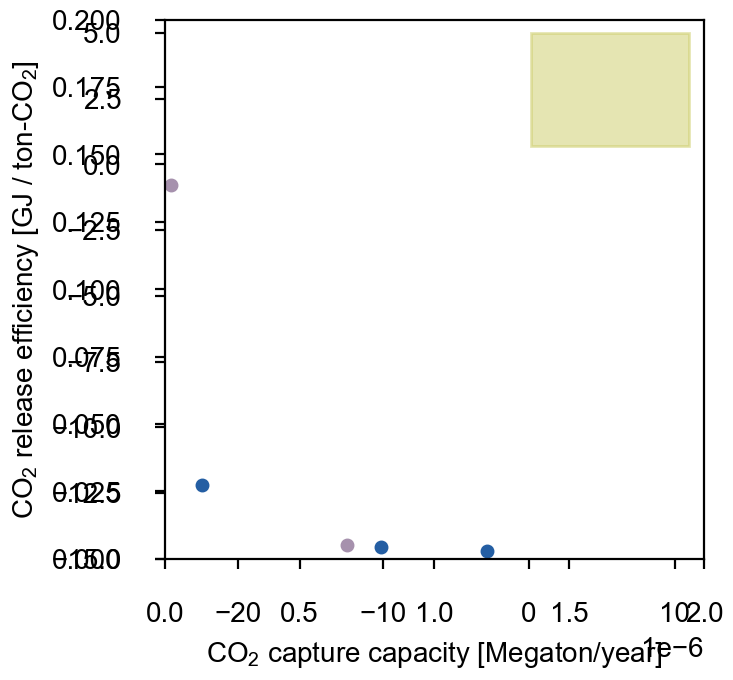

In [85]:
# Figure of CO2 efficiency against CO2 capture throughput

# co2_rel_rate_lim = -0.005, 0.06

# plt_exp = 0, 1, 2, 3, 9, 4 # degas - no cav. with check for contamination
# plt_exp1 = 0, 1, 2, 3, 9 # degas - no cav.
# table_caption1 = "Conductivity statistics for degassed experiments without cavitation."
# plt_exp2 = 5, 6, 7, 8, 13 # dis gas - no cav.
# table_caption2 = "Conductivity statistics for high dissolved CO2 experiments without cavitation."
plt_exp3 = 9, 10, 11, 12, 13 # K = 1.37
plt_col3 = (1, 0.26, 0.26)
# plt_exp4 = 14, 15, 16, 17 # K = 1.12
plt_exp4 = 16, 17 # K = 1.12
plt_col4 = (0.65, 0.57, 0.68)
# plt_exp5 = 18, 19, 20, 21, 22 # K = 1.06
plt_exp5 = 20, 21, 22 # K = 1.06
plt_col5 = (0.14, 0.37, 0.64)

# CP.PropsSI('D', 'T', 293.15, 'P', 14.7*6895, 'CO2')
co2_molemass = CP.PropsSI('CO2', 'molemass') # kg/mol
co2_mass_rel_rate = co2_conc_rel_rate * co2_molemass/60 # kg/s
co2_mass_rel_rate_ton = co2_mass_rel_rate*0.001 # ton/s
co2_mass_rel_rate_Mt_year = co2_mass_rel_rate_ton * 60 * 60 * 24 * 365 / 10**6 # mega ton/year

pump_power = delp_stats * qflow_stats / 10**9 # GW

co2_rel_efficiency = pump_power / co2_mass_rel_rate_ton # GJ / ton-CO2

fig = plt.figure()
ax1 = fig.add_axes([0.1, 0.1, 0.8, 0.8])


# ax.errorbar(co2_conc[plt_exp3, 0], co2_mass_rel_rate[plt_exp3, 0]/(qflow_stats[plt_exp3,0]*(dens1[plt_exp3,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp3, 1], fmt='o', markersize=4, label=f"Re = {Re_plt3[0]:.0f}; K = {CavNum_plt3[0]:.2f}", color=plt_col3, capsize=5, barsabove=True)
# ax.errorbar(co2_conc[plt_exp4, 0], co2_mass_rel_rate[plt_exp4, 0]/(qflow_stats[plt_exp4,0]*(dens1[plt_exp4,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp4, 1], fmt='o', markersize=4, label=f"Re = {Re_plt4[0]:.0f}; K = {CavNum_plt4[0]:.2f}", color=plt_col4, capsize=5, barsabove=True)
# ax.errorbar(co2_conc[plt_exp5, 0], co2_mass_rel_rate[plt_exp5, 0]/(qflow_stats[plt_exp5,0]*(dens1[plt_exp5,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp5, 1], fmt='o', markersize=4, label=f"Re = {Re_plt5[0]:.0f}; K = {CavNum_plt5[0]:.2f}", color=plt_col5, capsize=5, barsabove=True)
ax1.errorbar(co2_mass_rel_rate_Mt_year[plt_exp3, 0], co2_rel_efficiency[plt_exp3, 0], fmt='o', markersize=4, label=f"Re = {Re_plt3[0]:.0f}; K = {CavNum_plt3[0]:.2f}", color=plt_col3, capsize=5, barsabove=True)
ax1.errorbar(co2_mass_rel_rate_Mt_year[plt_exp4, 0], co2_rel_efficiency[plt_exp4, 0], fmt='o', markersize=4, label=f"Re = {Re_plt4[0]:.0f}; K = {CavNum_plt4[0]:.2f}", color=plt_col4, capsize=5, barsabove=True)
ax1.errorbar(co2_mass_rel_rate_Mt_year[plt_exp5, 0], co2_rel_efficiency[plt_exp5, 0], fmt='o', markersize=4, label=f"Re = {Re_plt5[0]:.0f}; K = {CavNum_plt5[0]:.2f}", color=plt_col5, capsize=5, barsabove=True)

ax1.set_xlabel('CO$_2$ capture capacity [Megaton/year]')
ax1.set_ylabel('CO$_2$ release efficiency [GJ / ton-CO$_2$]')
ax1.set_xlim(0, 2e-6);
ax1.set_ylim(0, 0.2);

# axs[1,0].grid(which='both', linestyle='--', linewidth=0.5, alpha=0.5)
# axs[0,0].legend(loc='upper left', bbox_to_anchor=(-0.5, 1.25), frameon=False, ncol=3);

ax2 = fig.add_axes(ax1.get_position(), frameon=False)
ax2.patch.set_facecolor('none')
ax2.add_patch(plt.Rectangle((0.1, 0.7), 10.9, 4.3, color=(0.8, 0.8, 0.4), alpha=0.5, label='Actual CCS'))
ax2.set_xlim(-25, 12);
ax2.set_ylim(-15, 5.5);


# # Define y limits
# axs[0].set_xlim(0, 1.5e-6);
# axs[1].set_xlim(1e-6, 11);

# axs[0].set_ylim(0, );

# # Define x limits
# axs[1,0].set_xlim(0, 1.5e-6);
# axs[0,0].set_xlim(0, 1.5e-6);
# axs[0,1].set_xlim(0.05, 12);
# axs[1,1].set_xlim(0.05, 12);


# # axs[1].errorbar(p3_mean[[plt_exp3]].flatten()/p2_stats[[plt_exp3],0].flatten(), co2_mass_rel_rate[plt_exp3, 0]/(qflow_stats[plt_exp3,0]*(dens1[plt_exp3,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp3, 1], fmt='o', markersize=4, label=f"Re = {Re_plt3[0]:.0f}; K = {CavNum_plt3[0]:.2f}", color=plt_col3, capsize=5, barsabove=True)
# # axs[1].errorbar(p3_mean[[plt_exp4]].flatten()/p2_stats[[plt_exp4],0].flatten(), co2_mass_rel_rate[plt_exp4, 0]/(qflow_stats[plt_exp4,0]*(dens1[plt_exp4,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp4, 1], fmt='o', markersize=4, label=f"Re = {Re_plt4[0]:.0f}; K = {CavNum_plt4[0]:.2f}", color=plt_col4, capsize=5, barsabove=True)
# # axs[1].errorbar(p3_mean[[plt_exp5]].flatten()/p2_stats[[plt_exp5],0].flatten(), co2_mass_rel_rate[plt_exp5, 0]/(qflow_stats[plt_exp5,0]*(dens1[plt_exp5,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp5, 1], fmt='o', markersize=4, label=f"Re = {Re_plt5[0]:.0f}; K = {CavNum_plt5[0]:.2f}", color=plt_col5, capsize=5, barsabove=True)
# axs[1].errorbar(p3_mean[[plt_exp3]].flatten()/p2_stats[[plt_exp3],0].flatten(), co2_rel_efficiency[plt_exp3, 0], fmt='o', markersize=4, label=f"Re = {Re_plt3[0]:.0f}; K = {CavNum_plt3[0]:.2f}", color=plt_col3, capsize=5, barsabove=True)
# axs[1].errorbar(p3_mean[[plt_exp4]].flatten()/p2_stats[[plt_exp4],0].flatten(), co2_rel_efficiency[plt_exp4, 0], fmt='o', markersize=4, label=f"Re = {Re_plt4[0]:.0f}; K = {CavNum_plt4[0]:.2f}", color=plt_col4, capsize=5, barsabove=True)
# axs[1].errorbar(p3_mean[[plt_exp5]].flatten()/p2_stats[[plt_exp5],0].flatten(), co2_rel_efficiency[plt_exp5, 0], fmt='o', markersize=4, label=f"Re = {Re_plt5[0]:.0f}; K = {CavNum_plt5[0]:.2f}", color=plt_col5, capsize=5, barsabove=True)
# axs[1].tick_params(axis='y', labelleft=False)
# axs[1].set_xlabel('p$_{CO2}$ / p$_2$ [-]')
# axs[1].grid(which='both', linestyle='--', linewidth=0.5, alpha=0.5)
# # axs[1].set_ylim(co2_rel_rate_lim);
# axs[1].set_ylim(0, );

plt.show()

C:\Users\sgun0045\AppData\Local\Temp\ipykernel_111308\1376571573.py:30: RuntimeWarning: divide by zero encountered in divide
  co2_rel_efficiency = pump_power / co2_mass_rel_rate_ton # GJ / ton-CO2


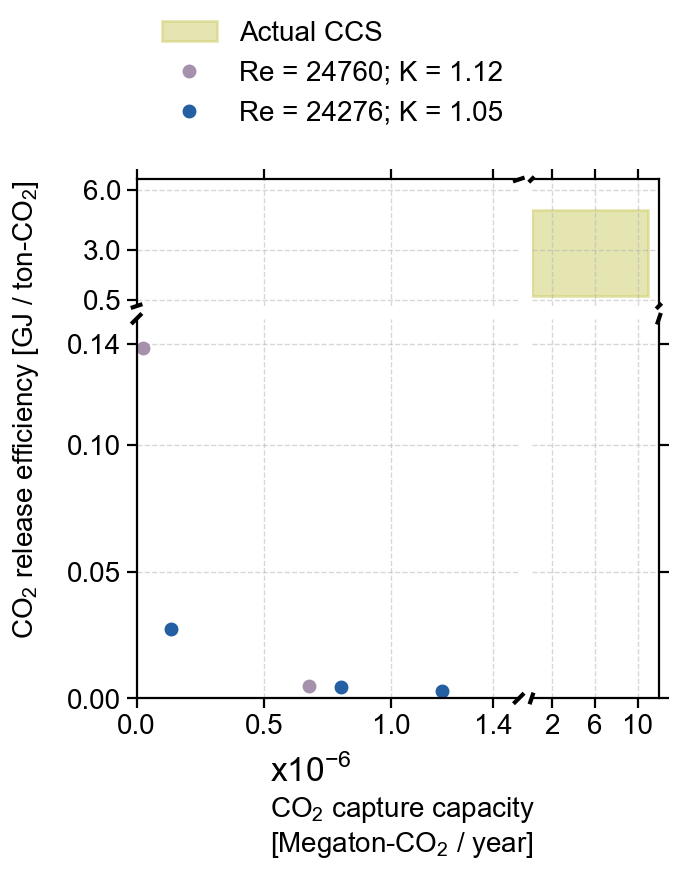

In [86]:
# Figure of CO2 efficiency against CO2 capture throughput

figsize = [3.37 ,3.37 ] # 1 column figure
matplotlib.rcParams['figure.figsize'] = figsize # 1 column figure

# co2_rel_rate_lim = -0.005, 0.06

# plt_exp = 0, 1, 2, 3, 9, 4 # degas - no cav. with check for contamination
# plt_exp1 = 0, 1, 2, 3, 9 # degas - no cav.
# table_caption1 = "Conductivity statistics for degassed experiments without cavitation."
# plt_exp2 = 5, 6, 7, 8, 13 # dis gas - no cav.
# table_caption2 = "Conductivity statistics for high dissolved CO2 experiments without cavitation."
plt_exp3 = 9, 10, 11, 12, 13 # K = 1.37
plt_col3 = (1, 0.26, 0.26)
# plt_exp4 = 14, 15, 16, 17 # K = 1.12
plt_exp4 = 16, 17 # K = 1.12
plt_col4 = (0.65, 0.57, 0.68)
# plt_exp5 = 18, 19, 20, 21, 22 # K = 1.06
plt_exp5 = 20, 21, 22 # K = 1.06
plt_col5 = (0.14, 0.37, 0.64)

# CP.PropsSI('D', 'T', 293.15, 'P', 14.7*6895, 'CO2')
co2_molemass = CP.PropsSI('CO2', 'molemass') # kg/mol
co2_mass_rel_rate = co2_conc_rel_rate * co2_molemass/60 # kg/s
co2_mass_rel_rate_ton = co2_mass_rel_rate*0.001 # ton/s
co2_mass_rel_rate_Mt_year = co2_mass_rel_rate_ton * 60 * 60 * 24 * 365 / 10**6 # mega ton/year

pump_power = delp_stats * qflow_stats / 10**9 # GW

co2_rel_efficiency = pump_power / co2_mass_rel_rate_ton # GJ / ton-CO2

fig, axs = plt.subplots(2,2, sharex='col', sharey='row', gridspec_kw={
        'width_ratios': [3, 1],
        'height_ratios': [1, 3],
        'wspace': 0.05,
        'hspace': 0.05
    })

# ax.errorbar(co2_conc[plt_exp3, 0], co2_mass_rel_rate[plt_exp3, 0]/(qflow_stats[plt_exp3,0]*(dens1[plt_exp3,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp3, 1], fmt='o', markersize=4, label=f"Re = {Re_plt3[0]:.0f}; K = {CavNum_plt3[0]:.2f}", color=plt_col3, capsize=5, barsabove=True)
# ax.errorbar(co2_conc[plt_exp4, 0], co2_mass_rel_rate[plt_exp4, 0]/(qflow_stats[plt_exp4,0]*(dens1[plt_exp4,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp4, 1], fmt='o', markersize=4, label=f"Re = {Re_plt4[0]:.0f}; K = {CavNum_plt4[0]:.2f}", color=plt_col4, capsize=5, barsabove=True)
# ax.errorbar(co2_conc[plt_exp5, 0], co2_mass_rel_rate[plt_exp5, 0]/(qflow_stats[plt_exp5,0]*(dens1[plt_exp5,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp5, 1], fmt='o', markersize=4, label=f"Re = {Re_plt5[0]:.0f}; K = {CavNum_plt5[0]:.2f}", color=plt_col5, capsize=5, barsabove=True)
# axs[1,0].errorbar(co2_mass_rel_rate_Mt_year[plt_exp3, 0], co2_rel_efficiency[plt_exp3, 0], fmt='o', markersize=4, label=f"Re = {Re_plt3[0]:.0f}; K = {CavNum_plt3[0]:.2f}", color=plt_col3, capsize=5, barsabove=True)
axs[1,0].errorbar(co2_mass_rel_rate_Mt_year[plt_exp4, 0], co2_rel_efficiency[plt_exp4, 0], fmt='o', markersize=4, label=f"Re = {Re_plt4[0]:.0f}; K = {CavNum_plt4[0]:.2f}", color=plt_col4, capsize=5, barsabove=True)
axs[1,0].errorbar(co2_mass_rel_rate_Mt_year[plt_exp5, 0], co2_rel_efficiency[plt_exp5, 0], fmt='o', markersize=4, label=f"Re = {Re_plt5[0]:.0f}; K = {CavNum_plt5[0]:.2f}", color=plt_col5, capsize=5, barsabove=True)
axs[1,0].add_patch(plt.Rectangle((0.1, 0.7), 10.9, 4.3, color=(0.8, 0.8, 0.4), alpha=0.5, label='Actual CCS'))

axs[0,1].add_patch(plt.Rectangle((0.1, 0.7), 10.9, 4.3, color=(0.8, 0.8, 0.4), alpha=0.5, label='Actual CCS'))

axs[1,0].set_xlabel('CO$_2$ capture capacity \n[Megaton-CO$_2$ / year]',loc='left', labelpad=15)
axs[0,0].set_ylabel('CO$_2$ release efficiency [GJ / ton-CO$_2$]', loc='top', labelpad=15)

# Gridlines
axs[0,0].grid(which='both', linestyle='--', linewidth=0.5, alpha=0.5)
axs[0,1].grid(which='both', linestyle='--', linewidth=0.5, alpha=0.5)
axs[1,0].grid(which='both', linestyle='--', linewidth=0.5, alpha=0.5)
axs[1,1].grid(which='both', linestyle='--', linewidth=0.5, alpha=0.5)
axs[1,0].legend(loc='upper left', bbox_to_anchor=(0, 1.85), frameon=False, ncol=1);


# Define y limits
axs[1,0].set_ylim(0, 0.15);
axs[1,1].set_ylim(0, );
axs[0,0].set_ylim(0.2, 6.5);
axs[0,1].set_ylim(0.2, 6.5);

# Define x limits
axs[1,0].set_xlim(0, 1.5e-6);
axs[0,0].set_xlim(0, 1.5e-6);
axs[0,1].set_xlim(0.05, 12);
axs[1,1].set_xlim(0.05, 12);


# Hide spines
for ax in axs[:, 1]:
    ax.spines['left'].set_visible(False)
    ax.yaxis.tick_right()

for ax in axs[:, 0]:
    ax.spines['right'].set_visible(False)
    ax.yaxis.tick_right()

for ax in axs[0, :]:
    ax.spines['bottom'].set_visible(False)
    ax.xaxis.tick_top()

for ax in axs[1, :]:
    ax.spines['top'].set_visible(False)
    ax.xaxis.tick_top()

# axs[0,0].tick_params(labeltop=False)
# axs[0,0].tick_params(axis='both', which='both', length=0)
axs[0,0].set_xticks([0, 0.5e-6, 1e-6, 1.4e-6])
axs[1,1].set_xticks([2, 6, 10])
axs[1,0].set_yticks([0, 0.05, 0.1, 0.14])
# axs[0,0].set_yticks([2, 4, 6])
axs[0,0].set_yticks([0.5, 3, 6])


axs[0,0].tick_params(labeltop=False, labelbottom=False, labelleft=True, labelright=False, bottom=False, right=False, left=True, pad=2)
axs[0,1].tick_params(labeltop=False, labelbottom=False, labelleft=False, labelright=False, bottom=False, left=False, right=False, pad=2)
axs[1,0].tick_params(labeltop=False, labelbottom=True, labelleft=True, labelright=False, top=False, right=False, bottom=True, left=True, pad=2)
axs[1,1].tick_params(labeltop=False, labelbottom=True, labelleft=False, labelright=False, top=False, bottom=True, pad=2)

# axs[1,0].ticklabel_format(axis='x', style='plain', useOffset=False)
axs[1,0].xaxis.get_offset_text().set_visible(False)
axs[1,0].annotate('x10$^{-6}$', xy=(0.35,-0.22), xycoords='axes fraction', fontsize=12)

# Diagonal break marks
d = 0.01
kwargs = dict(transform=axs[0, 0].transAxes, color='k', clip_on=False)
axs[0, 0].plot((-d, +d), (-d, +d), **kwargs)
axs[0, 0].plot((1-d, 1+d), (1-d, 1+d), **kwargs)

kwargs.update(transform=axs[0, 1].transAxes)
axs[0, 1].plot((-d, +d), (1-d, 1+d), **kwargs)
axs[0, 1].plot((1-d, 1+d), (-d, +d), **kwargs)

kwargs.update(transform=axs[1, 0].transAxes)
axs[1, 0].plot((-d, +d), (1-d, 1+d), **kwargs)
axs[1, 0].plot((1-d, 1+d), (-d, +d), **kwargs)

kwargs.update(transform=axs[1, 1].transAxes)
axs[1, 1].plot((-d, +d), (-d, +d), **kwargs)
axs[1, 1].plot((1-d, 1+d), (1-d, 1+d), **kwargs)

axs[1,0].xaxis.set_label_coords(0.35, -0.25)

# plt.show()

In [90]:
co2_rel_efficiency[plt_exp5, 0]

array([0.02732757, 0.00457449, 0.00301227])

In [ ]:
# Figure of CO2 efficiency against CO2 capture throughput

# co2_rel_rate_lim = -0.005, 0.06

# plt_exp = 0, 1, 2, 3, 9, 4 # degas - no cav. with check for contamination
# plt_exp1 = 0, 1, 2, 3, 9 # degas - no cav.
# table_caption1 = "Conductivity statistics for degassed experiments without cavitation."
# plt_exp2 = 5, 6, 7, 8, 13 # dis gas - no cav.
# table_caption2 = "Conductivity statistics for high dissolved CO2 experiments without cavitation."
plt_exp3 = 9, 10, 11, 12, 13 # K = 1.37
plt_col3 = (1, 0.26, 0.26)
# plt_exp4 = 14, 15, 16, 17 # K = 1.12
plt_exp4 = 16, 17 # K = 1.12
plt_col4 = (0.65, 0.57, 0.68)
# plt_exp5 = 18, 19, 20, 21, 22 # K = 1.06
plt_exp5 = 20, 21, 22 # K = 1.06
plt_col5 = (0.14, 0.37, 0.64)

# CP.PropsSI('D', 'T', 293.15, 'P', 14.7*6895, 'CO2')
co2_molemass = CP.PropsSI('CO2', 'molemass') # kg/mol
co2_mass_rel_rate = co2_conc_rel_rate * co2_molemass/60 # kg/s
co2_mass_rel_rate_ton = co2_mass_rel_rate*0.001 # ton/s
co2_mass_rel_rate_Mt_year = co2_mass_rel_rate_ton * 60 * 60 * 24 * 365 / 10**6 # mega ton/year

pump_power = delp_stats * qflow_stats / 10**9 # GW

co2_rel_efficiency = pump_power / co2_mass_rel_rate_ton # GJ / ton-CO2

fig, axs = plt.subplots(2,2, sharex='col', sharey='row', gridspec_kw={
        'width_ratios': [3, 1],
        'height_ratios': [1, 3],
        'wspace': 0.05,
        'hspace': 0.05
    })

# ax.errorbar(co2_conc[plt_exp3, 0], co2_mass_rel_rate[plt_exp3, 0]/(qflow_stats[plt_exp3,0]*(dens1[plt_exp3,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp3, 1], fmt='o', markersize=4, label=f"Re = {Re_plt3[0]:.0f}; K = {CavNum_plt3[0]:.2f}", color=plt_col3, capsize=5, barsabove=True)
# ax.errorbar(co2_conc[plt_exp4, 0], co2_mass_rel_rate[plt_exp4, 0]/(qflow_stats[plt_exp4,0]*(dens1[plt_exp4,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp4, 1], fmt='o', markersize=4, label=f"Re = {Re_plt4[0]:.0f}; K = {CavNum_plt4[0]:.2f}", color=plt_col4, capsize=5, barsabove=True)
# ax.errorbar(co2_conc[plt_exp5, 0], co2_mass_rel_rate[plt_exp5, 0]/(qflow_stats[plt_exp5,0]*(dens1[plt_exp5,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp5, 1], fmt='o', markersize=4, label=f"Re = {Re_plt5[0]:.0f}; K = {CavNum_plt5[0]:.2f}", color=plt_col5, capsize=5, barsabove=True)
axs[1,0].errorbar(co2_mass_rel_rate_Mt_year[plt_exp3, 0], co2_rel_efficiency[plt_exp3, 0], fmt='o', markersize=4, label=f"Re = {Re_plt3[0]:.0f}; K = {CavNum_plt3[0]:.2f}", color=plt_col3, capsize=5, barsabove=True)
axs[1,0].errorbar(co2_mass_rel_rate_Mt_year[plt_exp4, 0], co2_rel_efficiency[plt_exp4, 0], fmt='o', markersize=4, label=f"Re = {Re_plt4[0]:.0f}; K = {CavNum_plt4[0]:.2f}", color=plt_col4, capsize=5, barsabove=True)
axs[1,0].errorbar(co2_mass_rel_rate_Mt_year[plt_exp5, 0], co2_rel_efficiency[plt_exp5, 0], fmt='o', markersize=4, label=f"Re = {Re_plt5[0]:.0f}; K = {CavNum_plt5[0]:.2f}", color=plt_col5, capsize=5, barsabove=True)
axs[0,1].add_patch(plt.Rectangle((0.1, 0.7), 10.9, 4.3, color=(0.8, 0.8, 0.4), alpha=0.5, label='Actual CCS'))

axs[1,0].set_xlabel('CO$_2$ capture capacity [Megaton/year]')
axs[0,0].set_ylabel('CO$_2$ release efficiency [GJ / ton-CO$_2$]')
axs[1,0].grid(which='both', linestyle='--', linewidth=0.5, alpha=0.5)
axs[1,0].grid(which='both', linestyle='--', linewidth=0.5, alpha=0.5)
# axs[1,0].legend(loc='upper left', bbox_to_anchor=(-0.5, 1.25), frameon=False, ncol=3);


# Define y limits
axs[1,0].set_ylim(0, );
axs[1,1].set_ylim(0, );
axs[0,0].set_ylim(0.2, 6);
axs[0,1].set_ylim(0.2, 6);

# Define x limits
axs[1,0].set_xlim(0, 1.5e-6);
axs[0,0].set_xlim(0, 1.5e-6);
axs[0,1].set_xlim(0.05, 12);
axs[1,1].set_xlim(0.05, 12);


# Hide spines
for ax in axs[:, 1]:
    ax.spines['left'].set_visible(False)
    ax.yaxis.tick_right()

for ax in axs[:, 0]:
    ax.spines['right'].set_visible(False)
    ax.yaxis.tick_right()

for ax in axs[0, :]:
    ax.spines['bottom'].set_visible(False)
    ax.xaxis.tick_top()

for ax in axs[1, :]:
    ax.spines['top'].set_visible(False)
    ax.xaxis.tick_top()

# axs[0,0].tick_params(labeltop=False)
# axs[0,0].tick_params(axis='both', which='both', length=0)
# axs[0,0].set_xticks([])
# axs[1,1].set_yticks([])

axs[0,0].tick_params(labeltop=False, labelbottom=False, labelleft=True, labelright=False, bottom=False, right=False)
axs[0,1].tick_params(labeltop=False, labelbottom=False, labelleft=False, labelright=False, bottom=False, left=False, right=False)
axs[1,0].tick_params(labeltop=False, labelbottom=True, labelleft=True, labelright=False, top=False, right=False, bottom=True)
axs[1,1].tick_params(labeltop=False, labelbottom=True, labelleft=False, labelright=False, top=False, bottom=True)


# Diagonal break marks
d = 0.01
kwargs = dict(transform=axs[0, 0].transAxes, color='k', clip_on=False)
axs[0, 0].plot((-d, +d), (-d, +d), **kwargs)
axs[0, 0].plot((1-d, 1+d), (1-d, 1+d), **kwargs)

kwargs.update(transform=axs[0, 1].transAxes)
axs[0, 1].plot((-d, +d), (1-d, 1+d), **kwargs)
axs[0, 1].plot((1-d, 1+d), (-d, +d), **kwargs)

kwargs.update(transform=axs[1, 0].transAxes)
axs[1, 0].plot((-d, +d), (1-d, 1+d), **kwargs)
axs[1, 0].plot((1-d, 1+d), (-d, +d), **kwargs)

kwargs.update(transform=axs[1, 1].transAxes)
axs[1, 1].plot((-d, +d), (-d, +d), **kwargs)
axs[1, 1].plot((1-d, 1+d), (1-d, 1+d), **kwargs)

# # axs[1].errorbar(p3_mean[[plt_exp3]].flatten()/p2_stats[[plt_exp3],0].flatten(), co2_mass_rel_rate[plt_exp3, 0]/(qflow_stats[plt_exp3,0]*(dens1[plt_exp3,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp3, 1], fmt='o', markersize=4, label=f"Re = {Re_plt3[0]:.0f}; K = {CavNum_plt3[0]:.2f}", color=plt_col3, capsize=5, barsabove=True)
# # axs[1].errorbar(p3_mean[[plt_exp4]].flatten()/p2_stats[[plt_exp4],0].flatten(), co2_mass_rel_rate[plt_exp4, 0]/(qflow_stats[plt_exp4,0]*(dens1[plt_exp4,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp4, 1], fmt='o', markersize=4, label=f"Re = {Re_plt4[0]:.0f}; K = {CavNum_plt4[0]:.2f}", color=plt_col4, capsize=5, barsabove=True)
# # axs[1].errorbar(p3_mean[[plt_exp5]].flatten()/p2_stats[[plt_exp5],0].flatten(), co2_mass_rel_rate[plt_exp5, 0]/(qflow_stats[plt_exp5,0]*(dens1[plt_exp5,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp5, 1], fmt='o', markersize=4, label=f"Re = {Re_plt5[0]:.0f}; K = {CavNum_plt5[0]:.2f}", color=plt_col5, capsize=5, barsabove=True)
# axs[1].errorbar(p3_mean[[plt_exp3]].flatten()/p2_stats[[plt_exp3],0].flatten(), co2_rel_efficiency[plt_exp3, 0], fmt='o', markersize=4, label=f"Re = {Re_plt3[0]:.0f}; K = {CavNum_plt3[0]:.2f}", color=plt_col3, capsize=5, barsabove=True)
# axs[1].errorbar(p3_mean[[plt_exp4]].flatten()/p2_stats[[plt_exp4],0].flatten(), co2_rel_efficiency[plt_exp4, 0], fmt='o', markersize=4, label=f"Re = {Re_plt4[0]:.0f}; K = {CavNum_plt4[0]:.2f}", color=plt_col4, capsize=5, barsabove=True)
# axs[1].errorbar(p3_mean[[plt_exp5]].flatten()/p2_stats[[plt_exp5],0].flatten(), co2_rel_efficiency[plt_exp5, 0], fmt='o', markersize=4, label=f"Re = {Re_plt5[0]:.0f}; K = {CavNum_plt5[0]:.2f}", color=plt_col5, capsize=5, barsabove=True)
# axs[1].tick_params(axis='y', labelleft=False)
# axs[1].set_xlabel('p$_{CO2}$ / p$_2$ [-]')
# axs[1].grid(which='both', linestyle='--', linewidth=0.5, alpha=0.5)
# # axs[1].set_ylim(co2_rel_rate_lim);
# axs[1].set_ylim(0, );

plt.show()

C:\Users\sgun0045\AppData\Local\Temp\ipykernel_157552\814953000.py:27: RuntimeWarning: divide by zero encountered in divide
  co2_rel_efficiency = pump_power / co2_mass_rel_rate_ton # GJ / ton-CO2
C:\Users\sgun0045\AppData\Local\Temp\ipykernel_157552\814953000.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0,0].legend(loc='upper left', bbox_to_anchor=(-0.5, 1.25), frameon=False, ncol=3);


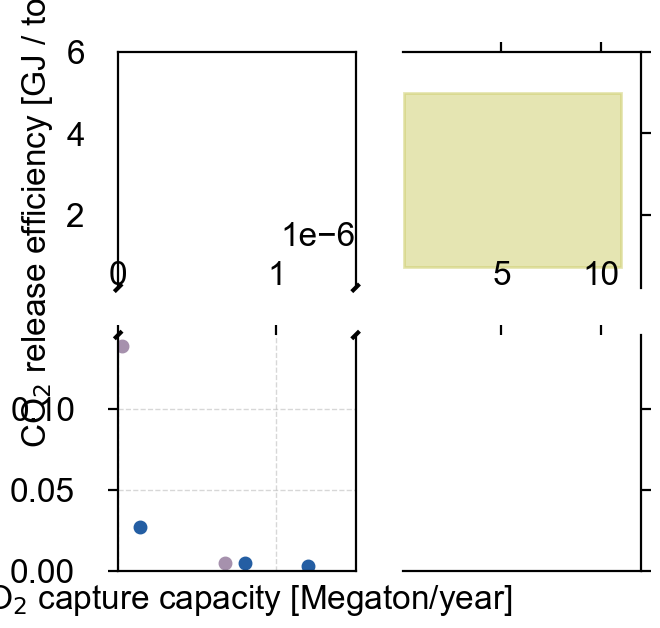

In [ ]:
# Figure of CO2 efficiency against CO2 capture throughput

# co2_rel_rate_lim = -0.005, 0.06

# plt_exp = 0, 1, 2, 3, 9, 4 # degas - no cav. with check for contamination
# plt_exp1 = 0, 1, 2, 3, 9 # degas - no cav.
# table_caption1 = "Conductivity statistics for degassed experiments without cavitation."
# plt_exp2 = 5, 6, 7, 8, 13 # dis gas - no cav.
# table_caption2 = "Conductivity statistics for high dissolved CO2 experiments without cavitation."
plt_exp3 = 9, 10, 11, 12, 13 # K = 1.37
plt_col3 = (1, 0.26, 0.26)
# plt_exp4 = 14, 15, 16, 17 # K = 1.12
plt_exp4 = 16, 17 # K = 1.12
plt_col4 = (0.65, 0.57, 0.68)
# plt_exp5 = 18, 19, 20, 21, 22 # K = 1.06
plt_exp5 = 20, 21, 22 # K = 1.06
plt_col5 = (0.14, 0.37, 0.64)

# CP.PropsSI('D', 'T', 293.15, 'P', 14.7*6895, 'CO2')
co2_molemass = CP.PropsSI('CO2', 'molemass') # kg/mol
co2_mass_rel_rate = co2_conc_rel_rate * co2_molemass/60 # kg/s
co2_mass_rel_rate_ton = co2_mass_rel_rate*0.001 # ton/s
co2_mass_rel_rate_Mt_year = co2_mass_rel_rate_ton * 60 * 60 * 24 * 365 / 10**6 # mega ton/year

pump_power = delp_stats * qflow_stats / 10**9 # GW

co2_rel_efficiency = pump_power / co2_mass_rel_rate_ton # GJ / ton-CO2

fig, axs = plt.subplots(2,2, sharex='col', sharey='row')

# ax.errorbar(co2_conc[plt_exp3, 0], co2_mass_rel_rate[plt_exp3, 0]/(qflow_stats[plt_exp3,0]*(dens1[plt_exp3,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp3, 1], fmt='o', markersize=4, label=f"Re = {Re_plt3[0]:.0f}; K = {CavNum_plt3[0]:.2f}", color=plt_col3, capsize=5, barsabove=True)
# ax.errorbar(co2_conc[plt_exp4, 0], co2_mass_rel_rate[plt_exp4, 0]/(qflow_stats[plt_exp4,0]*(dens1[plt_exp4,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp4, 1], fmt='o', markersize=4, label=f"Re = {Re_plt4[0]:.0f}; K = {CavNum_plt4[0]:.2f}", color=plt_col4, capsize=5, barsabove=True)
# ax.errorbar(co2_conc[plt_exp5, 0], co2_mass_rel_rate[plt_exp5, 0]/(qflow_stats[plt_exp5,0]*(dens1[plt_exp5,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp5, 1], fmt='o', markersize=4, label=f"Re = {Re_plt5[0]:.0f}; K = {CavNum_plt5[0]:.2f}", color=plt_col5, capsize=5, barsabove=True)
axs[1,0].errorbar(co2_mass_rel_rate_Mt_year[plt_exp3, 0], co2_rel_efficiency[plt_exp3, 0], fmt='o', markersize=4, label=f"Re = {Re_plt3[0]:.0f}; K = {CavNum_plt3[0]:.2f}", color=plt_col3, capsize=5, barsabove=True)
axs[1,0].errorbar(co2_mass_rel_rate_Mt_year[plt_exp4, 0], co2_rel_efficiency[plt_exp4, 0], fmt='o', markersize=4, label=f"Re = {Re_plt4[0]:.0f}; K = {CavNum_plt4[0]:.2f}", color=plt_col4, capsize=5, barsabove=True)
axs[1,0].errorbar(co2_mass_rel_rate_Mt_year[plt_exp5, 0], co2_rel_efficiency[plt_exp5, 0], fmt='o', markersize=4, label=f"Re = {Re_plt5[0]:.0f}; K = {CavNum_plt5[0]:.2f}", color=plt_col5, capsize=5, barsabove=True)
axs[0,1].add_patch(plt.Rectangle((0.1, 0.7), 10.9, 4.3, color=(0.8, 0.8, 0.4), alpha=0.5, label='Actual CCS'))

axs[1,0].set_xlabel('CO$_2$ capture capacity [Megaton/year]')
axs[0,0].set_ylabel('CO$_2$ release efficiency [GJ / ton-CO$_2$]')
axs[1,0].grid(which='both', linestyle='--', linewidth=0.5, alpha=0.5)
axs[0,0].legend(loc='upper left', bbox_to_anchor=(-0.5, 1.25), frameon=False, ncol=3);

# Define y limits
axs[1,0].set_ylim(0, );
axs[1,1].set_ylim(0, );
axs[0,0].set_ylim(0.2, 6);
axs[0,1].set_ylim(0.2, 6);

# Define x limits
axs[1,0].set_xlim(0, 1.5e-6);
axs[0,0].set_xlim(0, 1.5e-6);
axs[0,1].set_xlim(0.05, 12);
axs[1,1].set_xlim(0.05, 12);


# Hide spines
for ax in axs[:, 1]:
    ax.spines['left'].set_visible(False)
    ax.yaxis.tick_right()

# for ax in axs[:, 0]:
#     ax.spines['right'].set_visible(False)
#     ax.yaxis.tick_right()

for ax in axs[0, :]:
    ax.spines['bottom'].set_visible(False)
    ax.xaxis.tick_top()

for ax in axs[1, :]:
    ax.spines['top'].set_visible(False)
    ax.xaxis.tick_top()

# axs[0,0].tick_params(labeltop=False)
axs[0,0].tick_params(axis='both', which='both', length=0)
axs[0,0].tick_params(axis='both', which='both', length=0)



# Diagonal break marks
d = 0.01
kwargs = dict(transform=axs[0, 0].transAxes, color='k', clip_on=False)
axs[0, 0].plot((-d, +d), (-d, +d), **kwargs)
axs[0, 0].plot((1-d, 1+d), (-d, +d), **kwargs)

kwargs.update(transform=axs[1, 0].transAxes)
axs[1, 0].plot((-d, +d), (1-d, 1+d), **kwargs)
axs[1, 0].plot((1-d, 1+d), (1-d, 1+d), **kwargs)

# # axs[1].errorbar(p3_mean[[plt_exp3]].flatten()/p2_stats[[plt_exp3],0].flatten(), co2_mass_rel_rate[plt_exp3, 0]/(qflow_stats[plt_exp3,0]*(dens1[plt_exp3,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp3, 1], fmt='o', markersize=4, label=f"Re = {Re_plt3[0]:.0f}; K = {CavNum_plt3[0]:.2f}", color=plt_col3, capsize=5, barsabove=True)
# # axs[1].errorbar(p3_mean[[plt_exp4]].flatten()/p2_stats[[plt_exp4],0].flatten(), co2_mass_rel_rate[plt_exp4, 0]/(qflow_stats[plt_exp4,0]*(dens1[plt_exp4,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp4, 1], fmt='o', markersize=4, label=f"Re = {Re_plt4[0]:.0f}; K = {CavNum_plt4[0]:.2f}", color=plt_col4, capsize=5, barsabove=True)
# # axs[1].errorbar(p3_mean[[plt_exp5]].flatten()/p2_stats[[plt_exp5],0].flatten(), co2_mass_rel_rate[plt_exp5, 0]/(qflow_stats[plt_exp5,0]*(dens1[plt_exp5,0]*60)), yerr=2*co2_conc_rel_rate[plt_exp5, 1], fmt='o', markersize=4, label=f"Re = {Re_plt5[0]:.0f}; K = {CavNum_plt5[0]:.2f}", color=plt_col5, capsize=5, barsabove=True)
# axs[1].errorbar(p3_mean[[plt_exp3]].flatten()/p2_stats[[plt_exp3],0].flatten(), co2_rel_efficiency[plt_exp3, 0], fmt='o', markersize=4, label=f"Re = {Re_plt3[0]:.0f}; K = {CavNum_plt3[0]:.2f}", color=plt_col3, capsize=5, barsabove=True)
# axs[1].errorbar(p3_mean[[plt_exp4]].flatten()/p2_stats[[plt_exp4],0].flatten(), co2_rel_efficiency[plt_exp4, 0], fmt='o', markersize=4, label=f"Re = {Re_plt4[0]:.0f}; K = {CavNum_plt4[0]:.2f}", color=plt_col4, capsize=5, barsabove=True)
# axs[1].errorbar(p3_mean[[plt_exp5]].flatten()/p2_stats[[plt_exp5],0].flatten(), co2_rel_efficiency[plt_exp5, 0], fmt='o', markersize=4, label=f"Re = {Re_plt5[0]:.0f}; K = {CavNum_plt5[0]:.2f}", color=plt_col5, capsize=5, barsabove=True)
# axs[1].tick_params(axis='y', labelleft=False)
# axs[1].set_xlabel('p$_{CO2}$ / p$_2$ [-]')
# axs[1].grid(which='both', linestyle='--', linewidth=0.5, alpha=0.5)
# # axs[1].set_ylim(co2_rel_rate_lim);
# axs[1].set_ylim(0, );

plt.show()

#### pH sensor calibrations

- These checks have been done to establish if the pH measurements are dependent on the Reynolds number. 
- There is a statistical dependence of pH with Reynolds number. 0.06 difference across degassed cases and 0.13 difference across high concentration cases. The difference between extremities (High Re and low CO2 - Low Re and high CO2) is 0.98. Relative to this difference, the variation in pH with Reynolds number is significant (above 5%).
> SG - The degassed water pH is quite low (acidic). Make a measurement of the pH when the water is at rest (maybe after completing a degassed run). 

In [20]:
# Table for degassed and dissolved gas experiments without cavitation

# plt_exp = 0, 1, 2, 3, 9, 4 # degas - no cav. with check for contamination
plt_exp1 = 0, 1, 2, 3, 9 # degas - no cav.
table_caption1 = "pH statistics for degassed experiments without cavitation."
plt_exp2 = 5, 6, 7, 8, 13 # dis gas - no cav.
table_caption2 = "pH statistics for high dissolved CO2 experiments without cavitation."
# plt_exp = 9, 10, 11, 12, 13 # K = 1.37
# plt_exp = 14, 15, 16, 17 # K = 1.12
# plt_exp = 18, 19, 20, 21, 22 # K = 1.06

table_data1 = {}
for j in plt_exp1:
    table_data1[f"Re = {Re[j, 0]:.0f} \u00B1  {2*Re[j, 1]:.0f}"] = [f"{pH_stats[j, 0]:.2f} \u00B1  {2*pH_stats[j, 1]:.2f}", f"{co2_conc[j, 0]:.1f} \u00B1  {2*co2_conc[j, 1]:.1f}"]

df1 = pd.DataFrame(table_data1, index=["pH [-]", "Dissolved CO2 concentration [mol/m3]"])

display(df1.style.set_caption(table_caption1))


table_data2 = {}
for j in plt_exp2:
    table_data2[f"Re = {Re[j, 0]:.0f} \u00B1  {2*Re[j, 1]:.0f}"] = [f"{pH_stats[j, 0]:.2f} \u00B1  {2*pH_stats[j, 1]:.2f}", f"{co2_conc[j, 0]:.1f} \u00B1  {2*co2_conc[j, 1]:.1f}"]

df2 = pd.DataFrame(table_data2, index=["pH [-]", "Dissolved CO2 concentration [mol/m3]"])

display(df2.style.set_caption(table_caption2))


,Re = 9890 ± 125,Re = 14607 ± 133,Re = 18622 ± 132,Re = 21344 ± 135,Re = 23301 ± 129
pH [-],4.86 ± 0.03,4.90 ± 0.00,4.90 ± 0.01,4.91 ± 0.00,4.92 ± 0.00
Dissolved CO2 concentration [mol/m3],0.0 ± 0.1,0.0 ± 0.1,0.0 ± 0.1,0.0 ± 0.1,0.0 ± 0.1


,Re = 12185 ± 124,Re = 16194 ± 128,Re = 19313 ± 128,Re = 21908 ± 134,Re = 23767 ± 134
pH [-],3.94 ± 0.02,3.95 ± 0.03,4.02 ± 0.02,4.02 ± 0.02,4.07 ± 0.01
Dissolved CO2 concentration [mol/m3],110.5 ± 2.8,110.0 ± 2.8,109.2 ± 2.8,110.1 ± 2.8,111.4 ± 2.8


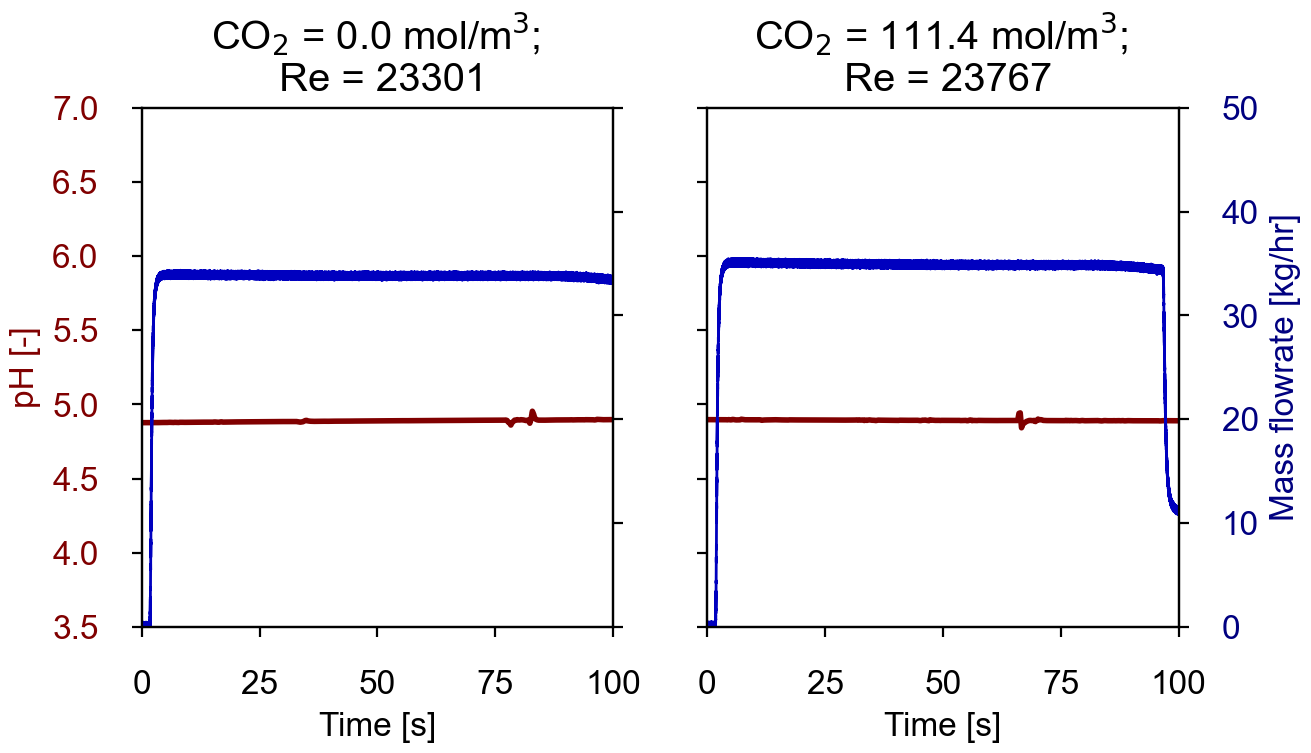

In [21]:
# Figure - Sample pH and mass flowrate signals

pH_lim = 3.5, 7
time_lim = 0, 100
mflow_lim = 0, 50

fig, axs = plt.subplots(1, 2)
axs_twin = np.empty_like(axs, dtype=object)

exp_num = 9
axs[0].plot(teensy_time[exp_num][:], pH_vals[exp_num][:], color=(0.5,0,0), linewidth=2)
axs[0].set_ylabel('pH [-]', color=(0.5,0,0))
axs[0].set_xlabel('Time [s]')
axs[0].set_xlim(time_lim)
axs[0].set_ylim(pH_lim)
axs[0].tick_params(axis='y', labelcolor=(0.5,0,0), labelleft=True)
axs[0].set_title(f"CO$_2$ = {co2_conc[exp_num,0]:.1f} mol/m$^3$; \n Re = {Re[exp_num,0]:.0f}")


axs_twin[0] = axs[0].twinx()
axs_twin[0].plot(ai_time[exp_num][1000:], f1_vals[exp_num][1000:], color=(0,0,0.75), linewidth=1, label='_Mass flowrate')
axs_twin[0].set_ylim(mflow_lim)
axs_twin[0].tick_params(axis='y', labelright=False)


exp_num = 13
axs[1].plot(teensy_time[exp_num][:], pH_vals[exp_num][:], color=(0.5,0,0), linewidth=2)
axs[1].set_xlabel('Time [s]')
axs[1].set_xlim(time_lim)
axs[1].set_ylim(pH_lim)
axs[1].tick_params(axis='y', labelleft=False)
axs[1].set_title(f"CO$_2$ = {co2_conc[exp_num,0]:.1f} mol/m$^3$; \n Re = {Re[exp_num,0]:.0f}")


axs_twin[1] = axs[1].twinx()
axs_twin[1].plot(ai_time[exp_num][1000:], f1_vals[exp_num][1000:], color=(0,0,0.75), linewidth=1, label='_Mass flowrate')
axs_twin[1].set_ylim(mflow_lim)
axs_twin[1].set_ylabel('Mass flowrate [kg/hr]', color=(0,0,0.5))
axs_twin[1].tick_params(axis='y', labelcolor=(0,0,0.5), labelright=True)

# plt.tight_layout()
plt.show()


- The following table shows the pH with the dissolved CO2 concentration when the flow is not cavitating.
> SG - Cite literature that has relationship between dissolved CO2 and pH. I think you need another measurement to directly compare but you can just plot the normalised values. 

In [22]:
# Table for varying dissolved CO2 concentration

# plt_exp = 0, 1, 2, 3, 9, 4 # degas - no cav. with check for contamination
# plt_exp1 = 0, 1, 2, 3, 9 # degas - no cav.
# table_caption1 = "Conductivity statistics for degassed experiments without cavitation."
# plt_exp2 = 5, 6, 7, 8, 13 # dis gas - no cav.
# table_caption2 = "Conductivity statistics for high dissolved CO2 experiments without cavitation."
plt_exp3 = 9, 10, 11, 12, 13 # K = 1.37
table_caption3 = "pH statistics with varying dissolved CO2 concentration without cavitation."
# plt_exp = 14, 15, 16, 17 # K = 1.12
# plt_exp = 18, 19, 20, 21, 22 # K = 1.06

table_data3 = {}
for j in plt_exp3:
    table_data3[f"[CO2] = {co2_conc[j, 0]:.1f} \u00B1  {2*co2_conc[j, 1]:.1f} mol/m3"] = [f"{pH_stats[j, 0]:.2f} \u00B1  {2*pH_stats[j, 1]:.2f}", f"{Re[j, 0]:.0f} \u00B1  {2*Re[j, 1]:.0f}", f"{CavNum[j, 0]:.2f} \u00B1  {2*CavNum[j, 1]:.2f}"]

df3 = pd.DataFrame(table_data3, index=["pH [-]", "Reynolds number [-]", "Cavitation number [-]"])

display(df3.style.set_caption(table_caption3))

,[CO2] = 0.0 ± 0.1 mol/m3,[CO2] = 26.1 ± 2.8 mol/m3,[CO2] = 54.6 ± 2.8 mol/m3,[CO2] = 82.5 ± 2.8 mol/m3,[CO2] = 111.4 ± 2.8 mol/m3
pH [-],4.92 ± 0.00,4.36 ± 0.02,4.21 ± 0.01,4.12 ± 0.02,4.07 ± 0.01
Reynolds number [-],23301 ± 129,23559 ± 147,23503 ± 141,23488 ± 134,23767 ± 134
Cavitation number [-],1.39 ± 0.00,1.37 ± 0.00,1.37 ± 0.00,1.37 ± 0.00,1.37 ± 0.00


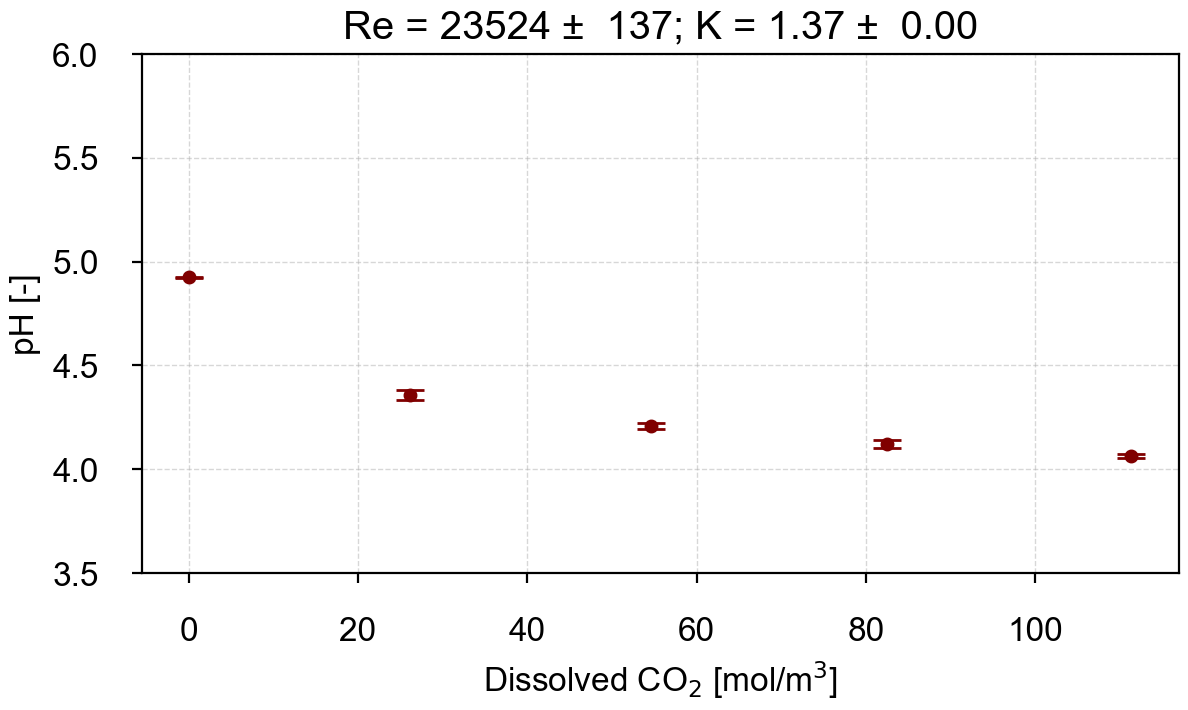

In [23]:
# Figure for pH vs dissolved CO2 concentration when not cavitating

pH_lim = 3.5, 6

# plt_exp = 0, 1, 2, 3, 9, 4 # degas - no cav. with check for contamination
# plt_exp1 = 0, 1, 2, 3, 9 # degas - no cav.
# table_caption1 = "Conductivity statistics for degassed experiments without cavitation."
# plt_exp2 = 5, 6, 7, 8, 13 # dis gas - no cav.
# table_caption2 = "Conductivity statistics for high dissolved CO2 experiments without cavitation."
plt_exp3 = 9, 10, 11, 12, 13 # K = 1.37
# plt_exp = 14, 15, 16, 17 # K = 1.12
# plt_exp = 18, 19, 20, 21, 22 # K = 1.06

# Assuming that the number of samples are so high so combining the standard deviations without the sample size factor is fine
CavNum_plt = []
CavNum_plt.append(np.mean(CavNum[plt_exp3, 0]))
CavNum_plt.append(np.sqrt(np.sum(CavNum[plt_exp3, 1]**2)/np.size(plt_exp3)))

Re_plt = []
Re_plt.append(np.mean(Re[plt_exp3, 0]))
Re_plt.append(np.sqrt(np.sum(Re[plt_exp3, 1]**2)/np.size(plt_exp3)))

fig, ax = plt.subplots()

ax.errorbar(co2_conc[plt_exp3, 0], pH_stats[plt_exp3, 0], yerr=2*pH_stats[plt_exp3, 1], fmt='o', markersize=4, label='_pH', color=(0.5,0,0), capsize=5, barsabove=True)
ax.set_xlabel('Dissolved CO$_2$ [mol/m$^3$]')
ax.set_ylabel('pH [-]')
ax.grid(which='both', linestyle='--', linewidth=0.5, alpha=0.5)
ax.set_title(f"Re = {Re_plt[0]:.0f} \u00B1  {2*Re_plt[1]:.0f}; K = {CavNum_plt[0]:.2f} \u00B1  {2*CavNum_plt[1]:.2f}");
ax.set_ylim(pH_lim)

plt.show()


#### Quantification of gas release - pH

- The upstream conductivity provides confidence that there should be very little gas release happening there. So, might be able to get away with just the single pH sensor.
> SG - The difference in pH for degassed between cases might have issues.
>> SG - Rerun the [CO2] = 0 M and K = 1.06 case to confirm whether pH is close to 5.5.
- The calibration pH values were fit to a cubic spline and used to calculate the amount of gas release.
- The gas release calculated was about half of what was detected using the conductivity meters for K = 1.06.
- No gas release was detected for K = 1.12 cases at all.

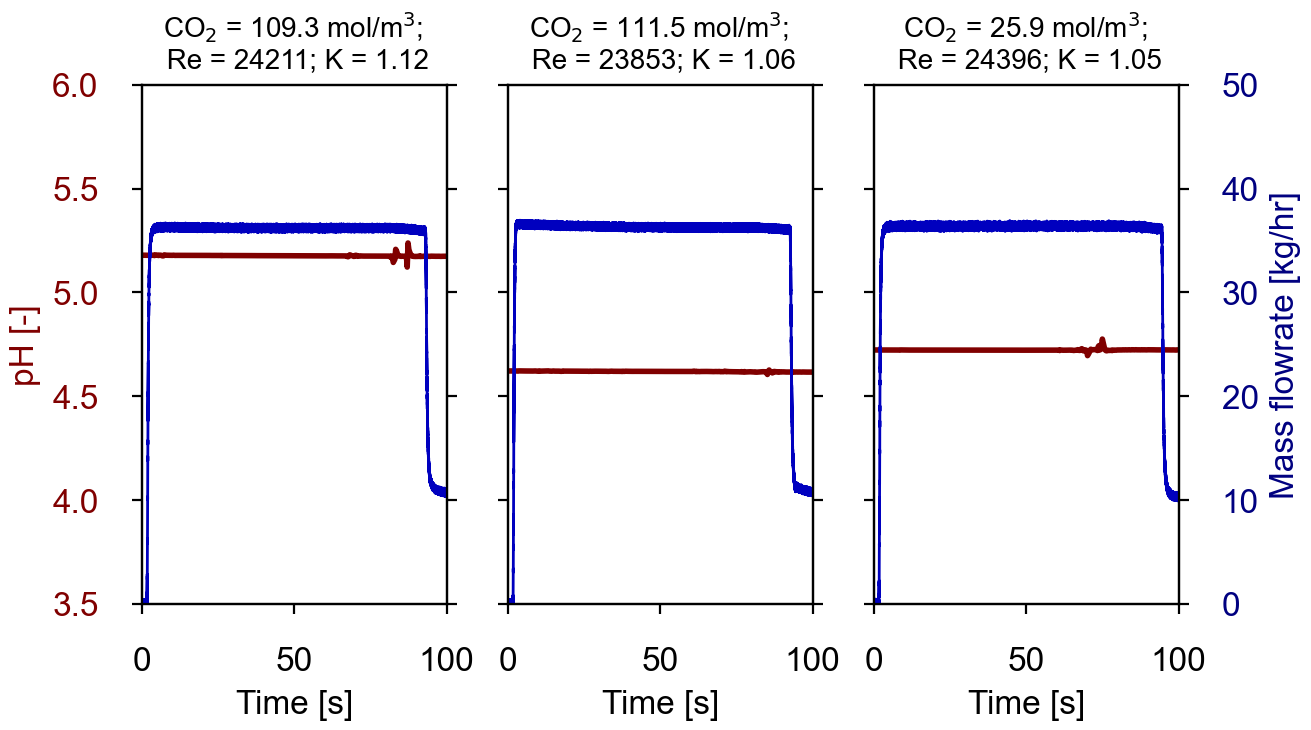

In [24]:
# Figure - Examples of pH signals with cavitiation

pH_lim = 3.5, 6
time_lim = 0, 100
mflow_lim = 0, 50

fig, axs = plt.subplots(1, 3)
axs_twin = np.empty_like(axs, dtype=object)

exp_num = 17
axs[0].plot(teensy_time[exp_num][:], pH_vals[exp_num][:], color=(0.5,0,0), linewidth=2)
axs[0].set_ylabel('pH [-]', color=(0.5,0,0))
axs[0].set_xlabel('Time [s]')
axs[0].set_xlim(time_lim)
axs[0].set_ylim(pH_lim)
axs[0].tick_params(axis='y', labelcolor=(0.5,0,0), labelleft=True)
# axs[0].legend(loc='upper left', bbox_to_anchor=(0.05, 1.35), ncol=2, frameon=False);
axs[0].set_title(f"CO$_2$ = {co2_conc[exp_num,0]:.1f} mol/m$^3$; \n Re = {Re[exp_num,0]:.0f}; K = {CavNum[exp_num,0]:.2f}", fontsize=10)


axs_twin[0] = axs[0].twinx()
axs_twin[0].plot(ai_time[exp_num][1000:], f1_vals[exp_num][1000:], color=(0,0,0.75), linewidth=1, label='_Mass flowrate')
axs_twin[0].set_ylim(mflow_lim)
axs_twin[0].tick_params(axis='y', labelright=False)


exp_num = 22
axs[1].plot(teensy_time[exp_num][:], pH_vals[exp_num][:], color=(0.5,0,0), linewidth=2)
axs[1].set_xlabel('Time [s]')
axs[1].set_xlim(time_lim)
axs[1].set_ylim(pH_lim)
axs[1].tick_params(axis='y', labelleft=False)
axs[1].set_title(f"CO$_2$ = {co2_conc[exp_num,0]:.1f} mol/m$^3$; \n Re = {Re[exp_num,0]:.0f}; K = {CavNum[exp_num,0]:.2f}", fontsize=10)


axs_twin[1] = axs[1].twinx()
axs_twin[1].plot(ai_time[exp_num][1000:], f1_vals[exp_num][1000:], color=(0,0,0.75), linewidth=1, label='_Mass flowrate')
axs_twin[1].set_ylim(mflow_lim)
axs_twin[1].tick_params(axis='y', labelright=False)


exp_num = 19
axs[2].plot(teensy_time[exp_num][:], pH_vals[exp_num][:], color=(0.5,0,0), linewidth=2)
axs[2].set_xlabel('Time [s]')
axs[2].set_xlim(time_lim)
axs[2].set_ylim(pH_lim)
axs[2].tick_params(axis='y', labelleft=False)
axs[2].set_title(f"CO$_2$ = {co2_conc[exp_num,0]:.1f} mol/m$^3$; \n Re = {Re[exp_num,0]:.0f}; K = {CavNum[exp_num,0]:.2f}", fontsize=10)


axs_twin[2] = axs[2].twinx()
axs_twin[2].plot(ai_time[exp_num][1000:], f1_vals[exp_num][1000:], color=(0,0,0.75), linewidth=1, label='_Mass flowrate')
axs_twin[2].set_ylim(mflow_lim)
axs_twin[2].set_ylabel('Mass flowrate [kg/hr]', color=(0,0,0.5))
axs_twin[2].tick_params(axis='y', labelcolor=(0,0,0.5), labelright=True)

# plt.tight_layout()
plt.show()


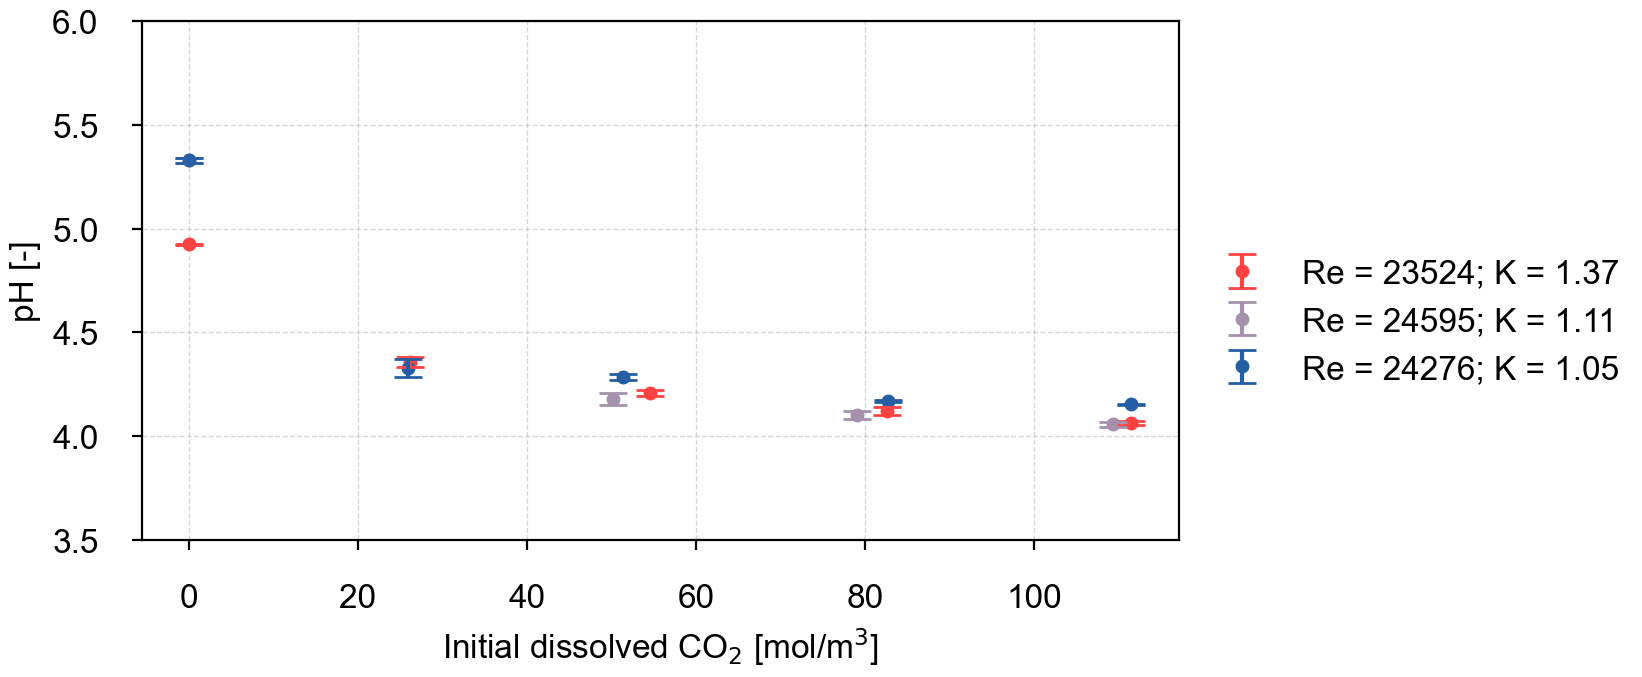

In [25]:
# Figure for pH vs dissolved CO2 concentration when not cavitating

pH_lim = 3.5, 6

# plt_exp = 0, 1, 2, 3, 9, 4 # degas - no cav. with check for contamination
# plt_exp1 = 0, 1, 2, 3, 9 # degas - no cav.
# table_caption1 = "Conductivity statistics for degassed experiments without cavitation."
# plt_exp2 = 5, 6, 7, 8, 13 # dis gas - no cav.
# table_caption2 = "Conductivity statistics for high dissolved CO2 experiments without cavitation."
plt_exp3 = 9, 10, 11, 12, 13 # K = 1.37
plt_col3 = (1, 0.26, 0.26)
plt_exp4 = 14, 15, 16, 17 # K = 1.12
plt_col4 = (0.65, 0.57, 0.68)
plt_exp5 = 18, 19, 20, 21, 22 # K = 1.06
plt_col5 = (0.14, 0.37, 0.64)

# Assuming that the number of samples are so high so combining the standard deviations without the sample size factor is fine
CavNum_plt3 = []
CavNum_plt3.append(np.mean(CavNum[plt_exp3, 0]))
CavNum_plt3.append(np.sqrt(np.sum(CavNum[plt_exp3, 1]**2)/np.size(plt_exp3)))
Re_plt3 = []
Re_plt3.append(np.mean(Re[plt_exp3, 0]))
Re_plt3.append(np.sqrt(np.sum(Re[plt_exp3, 1]**2)/np.size(plt_exp3)))

CavNum_plt4 = []
CavNum_plt4.append(np.mean(CavNum[plt_exp4, 0]))
CavNum_plt4.append(np.sqrt(np.sum(CavNum[plt_exp4, 1]**2)/np.size(plt_exp4)))
Re_plt4 = []
Re_plt4.append(np.mean(Re[plt_exp4, 0]))
Re_plt4.append(np.sqrt(np.sum(Re[plt_exp4, 1]**2)/np.size(plt_exp4)))

CavNum_plt5 = []
CavNum_plt5.append(np.mean(CavNum[plt_exp5, 0]))
CavNum_plt5.append(np.sqrt(np.sum(CavNum[plt_exp5, 1]**2)/np.size(plt_exp5)))
Re_plt5 = []
Re_plt5.append(np.mean(Re[plt_exp5, 0]))
Re_plt5.append(np.sqrt(np.sum(Re[plt_exp5, 1]**2)/np.size(plt_exp5)))

fig, axs = plt.subplots()

axs.errorbar(co2_conc[plt_exp3, 0], pH_stats[plt_exp3, 0], yerr=2*pH_stats[plt_exp3, 1], fmt='o', markersize=4, label=f"Re = {Re_plt3[0]:.0f}; K = {CavNum_plt3[0]:.2f}", color=plt_col3, capsize=5, barsabove=True)
axs.errorbar(co2_conc[plt_exp4, 0], pH_stats[plt_exp4, 0], yerr=2*pH_stats[plt_exp4, 1], fmt='o', markersize=4, label=f"Re = {Re_plt4[0]:.0f}; K = {CavNum_plt4[0]:.2f}", color=plt_col4, capsize=5, barsabove=True)
axs.errorbar(co2_conc[plt_exp5, 0], pH_stats[plt_exp5, 0], yerr=2*pH_stats[plt_exp5, 1], fmt='o', markersize=4, label=f"Re = {Re_plt5[0]:.0f}; K = {CavNum_plt5[0]:.2f}", color=plt_col5, capsize=5, barsabove=True)
axs.set_xlabel('Initial dissolved CO$_2$ [mol/m$^3$]')
axs.set_ylabel('pH [-]')
axs.grid(which='both', linestyle='--', linewidth=0.5, alpha=0.5)
axs.legend(loc='upper left', bbox_to_anchor=(1, 0.6), frameon=False, ncol=1);
# axs.set_title("Upstream");
axs.set_ylim(pH_lim);



plt.show()


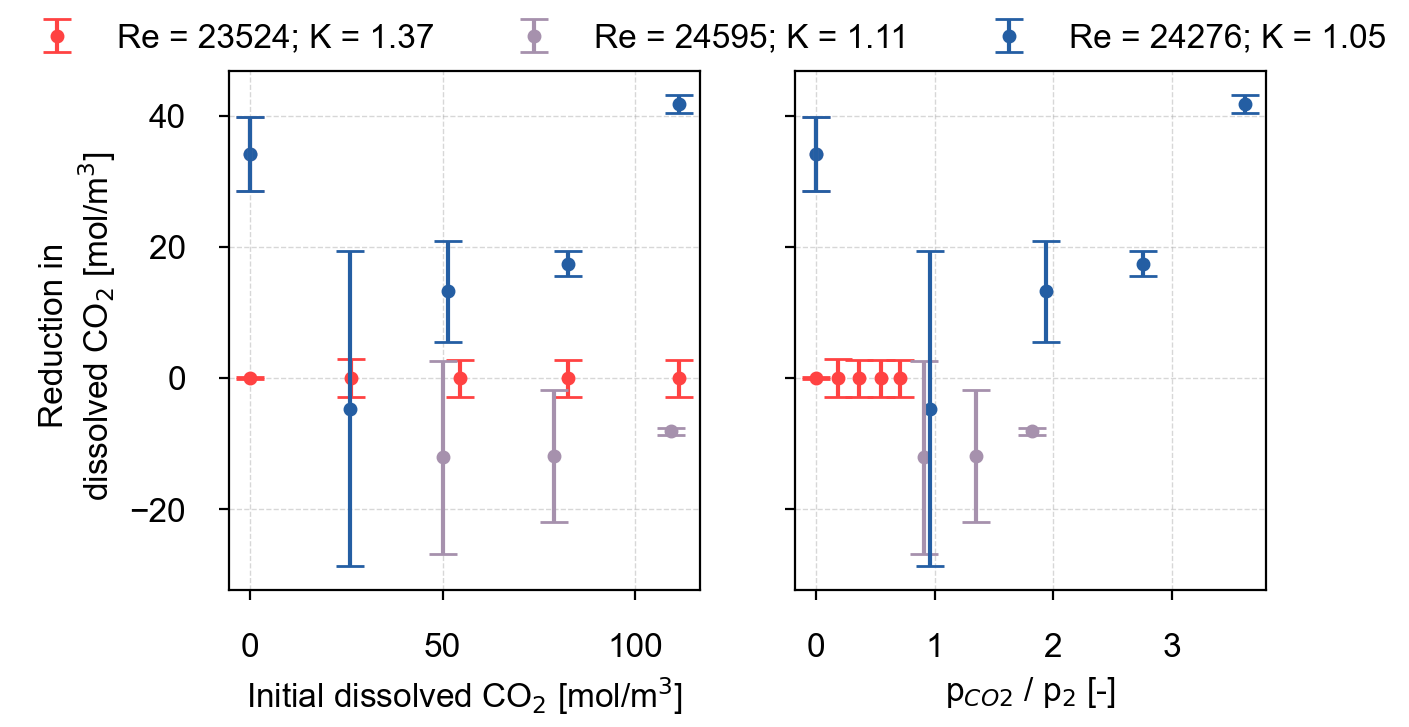

In [26]:
co2_rel_lim = -10, 90
from scipy.interpolate import interp1d

# plt_exp = 0, 1, 2, 3, 9, 4 # degas - no cav. with check for contamination
# plt_exp1 = 0, 1, 2, 3, 9 # degas - no cav.
# table_caption1 = "pH statistics for degassed experiments without cavitation."
# plt_exp2 = 5, 6, 7, 8, 13 # dis gas - no cav.
# table_caption2 = "pH statistics for high dissolved CO2 experiments without cavitation."
plt_exp3 = 9, 10, 11, 12, 13 # K = 1.37
plt_col3 = (1, 0.26, 0.26)
plt_exp4 = 14, 15, 16, 17 # K = 1.12
plt_col4 = (0.65, 0.57, 0.68)
plt_exp5 = 18, 19, 20, 21, 22 # K = 1.06
plt_col5 = (0.14, 0.37, 0.64)

spl = interp1d(pH_stats[plt_exp3, 0], co2_conc[plt_exp3, 0], kind='cubic', fill_value="extrapolate")

co2_conc_rel_pH = np.zeros_like(co2_conc)
co2_conc_rel_pH[:, 0] = (co2_conc[:, 0] - spl(pH_stats[:, 0]))
temp_var =  np.gradient(co2_conc[plt_exp3, 0])/np.gradient(pH_stats[plt_exp3, 0])
temp_var = np.interp(pH_stats[:, 0], pH_stats[plt_exp3, 0], temp_var)
co2_conc_rel_pH[:, 1] = np.sqrt((temp_var*pH_stats[:, 1])**2)
co2_conc_rel_pH[plt_exp3, 1] = co2_conc[plt_exp3, 1] # use original uncertainty for calibration points

fig, axs = plt.subplots(1, 2)

axs[0].errorbar(co2_conc[plt_exp3, 0], co2_conc_rel_pH[plt_exp3, 0], yerr=2*co2_conc_rel_pH[plt_exp3, 1], fmt='o', markersize=4, label=f"Re = {Re_plt3[0]:.0f}; K = {CavNum_plt3[0]:.2f}", color=plt_col3, capsize=5, barsabove=True)
axs[0].errorbar(co2_conc[plt_exp4, 0], co2_conc_rel_pH[plt_exp4, 0], yerr=2*co2_conc_rel_pH[plt_exp4, 1], fmt='o', markersize=4, label=f"Re = {Re_plt4[0]:.0f}; K = {CavNum_plt4[0]:.2f}", color=plt_col4, capsize=5, barsabove=True)
axs[0].errorbar(co2_conc[plt_exp5, 0], co2_conc_rel_pH[plt_exp5, 0], yerr=2*co2_conc_rel_pH[plt_exp5, 1], fmt='o', markersize=4, label=f"Re = {Re_plt5[0]:.0f}; K = {CavNum_plt5[0]:.2f}", color=plt_col5, capsize=5, barsabove=True)
axs[0].set_xlabel('Initial dissolved CO$_2$ [mol/m$^3$]')
axs[0].set_ylabel('Reduction in \n dissolved CO$_2$ [mol/m$^3$]')
axs[0].grid(which='both', linestyle='--', linewidth=0.5, alpha=0.5)
axs[0].legend(loc='upper left', bbox_to_anchor=(-0.5, 1.15), frameon=False, ncol=3);
# axs[0].set_ylim(co2_rel_lim);

axs[1].errorbar(p3_mean[[plt_exp3]].flatten()/p2_stats[[plt_exp3],0].flatten(), co2_conc_rel_pH[plt_exp3, 0], yerr=2*co2_conc_rel_pH[plt_exp3, 1], fmt='o', markersize=4, label=f"Re = {Re_plt3[0]:.0f}; K = {CavNum_plt3[0]:.2f}", color=plt_col3, capsize=5, barsabove=True)
axs[1].errorbar(p3_mean[[plt_exp4]].flatten()/p2_stats[[plt_exp4],0].flatten(), co2_conc_rel_pH[plt_exp4, 0], yerr=2*co2_conc_rel_pH[plt_exp4, 1], fmt='o', markersize=4, label=f"Re = {Re_plt4[0]:.0f}; K = {CavNum_plt4[0]:.2f}", color=plt_col4, capsize=5, barsabove=True)
axs[1].errorbar(p3_mean[[plt_exp5]].flatten()/p2_stats[[plt_exp5],0].flatten(), co2_conc_rel_pH[plt_exp5, 0], yerr=2*co2_conc_rel_pH[plt_exp5, 1], fmt='o', markersize=4, label=f"Re = {Re_plt5[0]:.0f}; K = {CavNum_plt5[0]:.2f}", color=plt_col5, capsize=5, barsabove=True)
axs[1].tick_params(axis='y', labelleft=False)
axs[1].set_xlabel('p$_{CO2}$ / p$_2$ [-]')
axs[1].grid(which='both', linestyle='--', linewidth=0.5, alpha=0.5)
# axs[1].set_ylim(co2_rel_lim);
